# 05 — H₂ Yield Predictive Modelling

## Project: H₂ Yield Prediction from Dark Fermentation Process Data

This notebook develops and evaluates machine learning models for predicting
hydrogen yield (`h2_yield`) using the validated synthetic dataset generated
through the Bootstrap-Jitter method.

The final synthetic dataset contains 6,000 observations representing six
food-to-microorganism (F/M) ratios:

- 0.5
- 1.0
- 1.5
- 2.0
- 2.5
- 3.0

A total of 1,000 synthetic observations were generated for each F/M ratio.

Bootstrap-Jitter with a jitter factor of 0.08 was selected during synthetic
data generator benchmarking. The resulting dataset successfully passed:

- Physical plausibility validation
- Statistical fidelity validation
- Correlation structure validation
- H₂-yield relationship validation
- Outlier-frequency validation

## Important Modelling Consideration

The 6,000 synthetic observations originate from only 61 experimental
observations.

Therefore, a conventional random train-test split may cause information
leakage because synthetic descendants of the same experimental observation
could appear in both training and testing datasets.

This notebook therefore prioritizes leakage-aware model evaluation before
predictive model selection.

## Notebook Objectives

1. Load and inspect the validated synthetic dataset
2. Audit the dataset for source-row provenance information
3. Define predictor and target variables
4. Design a leakage-aware validation strategy
5. Establish baseline model performance
6. Train multiple regression algorithms
7. Compare predictive performance
8. Tune the strongest candidate models
9. Evaluate the final model
10. Interpret feature importance and H₂-yield drivers
11. Save the final predictive pipeline

## 1. Import Required Libraries

The libraries required for data handling, visualization, preprocessing,
machine learning, and model evaluation are imported below.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from sklearn.model_selection import (
    train_test_split,
    GroupShuffleSplit,
    GroupKFold,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyRegressor

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Validated Synthetic Dataset

The validated Bootstrap-Jitter synthetic dataset is loaded from the project
data directory.

The dataset contains 6,000 observations, with 1,000 observations for each
F/M ratio.

In [2]:
DATA_PATH = Path(
    r"D:\Data Science Projects\Hydrogen yield predictor\data\h2_data.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

df.head()

Dataset loaded successfully.
Dataset shape: (6000, 17)


,source_id,substrate_mc,substrate_ts,substrate_vs,substrate_fs,inoculum_mc,inoculum_ts,inoculum_vs,inoculum_fs,scod,tcod,scod_tcod_ratio,trs,lignin,hmf,fm_ratio,h2_yield
0,EXP_001,5.2580,94.7420,89.4140,10.5860,89.9175,10.0825,90.2975,9.7025,"5,994.4786","11,361.4872",0.5276,1.0106,25.3805,45.4082,0.5000,21.8682
1,EXP_009,5.9831,94.0169,82.3495,17.6505,87.4575,12.5425,93.4155,6.5845,"6,456.7760","12,404.2914",0.5205,5.6784,18.9373,"1,151.1505",0.5000,0.0000
2,EXP_008,5.0194,94.9806,84.8336,15.1664,91.9822,8.0178,90.6862,9.3138,"7,830.2136","14,368.4095",0.5450,1.1187,18.5368,101.8614,0.5000,19.7448
3,EXP_005,5.9381,94.0619,78.6778,21.3222,93.7581,6.2419,84.9544,15.0456,"6,007.7834","11,409.9489",0.5265,22.6297,20.1060,2.5273,0.5000,19.4090
4,EXP_005,5.9343,94.0657,78.1312,21.8688,93.7550,6.2450,84.9980,15.0020,"5,915.5690","11,406.9289",0.5186,21.8364,20.3369,38.0738,0.5000,19.9548


## 3. Initial Dataset Inspection

Before defining the machine learning workflow, the dataset structure,
variable names, data types, missing values, and F/M ratio distribution are
inspected.

This step also checks whether source experimental observation identifiers
were retained during synthetic data generation.

In [3]:
print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

df.info()

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(df.isnull().sum())

print("\n" + "=" * 70)
print("F/M RATIO DISTRIBUTION")
print("=" * 70)

print(
    df["fm_ratio"]
    .value_counts()
    .sort_index()
)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_id        6000 non-null   object 
 1   substrate_mc     6000 non-null   float64
 2   substrate_ts     6000 non-null   float64
 3   substrate_vs     6000 non-null   float64
 4   substrate_fs     6000 non-null   float64
 5   inoculum_mc      6000 non-null   float64
 6   inoculum_ts      6000 non-null   float64
 7   inoculum_vs      6000 non-null   float64
 8   inoculum_fs      6000 non-null   float64
 9   scod             6000 non-null   float64
 10  tcod             6000 non-null   float64
 11  scod_tcod_ratio  6000 non-null   float64
 12  trs              6000 non-null   float64
 13  lignin           6000 non-null   float64
 14  hmf              6000 non-null   float64
 15  fm_ratio         6000 non-null   float64
 16  h2_yield         6000 non-null   float64

## 4. Synthetic Data Provenance and Leakage Audit

The synthetic dataset was generated from 61 experimental observations using
Bootstrap-Jitter sampling.

Synthetic observations derived from the same experimental observation are
not fully independent. If descendants of one experimental observation are
randomly distributed between training and testing datasets, the model may be
evaluated on observations that are extremely similar to observations already
seen during training.

This can inflate predictive performance and produce an overly optimistic
estimate of model generalization.

The following audit checks whether a source observation identifier or other
provenance variable is available in the synthetic dataset.

In [4]:
possible_group_columns = [
    "source_id",
    "source_row_id",
    "original_id",
    "experimental_id",
    "experiment_id",
    "parent_id",
    "bootstrap_source_id"
]

available_group_columns = [
    column
    for column in possible_group_columns
    if column in df.columns
]

print("=" * 70)
print("PROVENANCE AUDIT")
print("=" * 70)

if available_group_columns:
    print("Potential provenance column(s) detected:")
    
    for column in available_group_columns:
        print(
            f"- {column}: "
            f"{df[column].nunique()} unique groups"
        )
else:
    print("No source observation identifier was detected.")
    print()
    print(
        "WARNING: A conventional random train-test split may cause "
        "synthetic sibling leakage."
    )

PROVENANCE AUDIT
Potential provenance column(s) detected:
- source_id: 61 unique groups


## 5. Define Target, Predictors, and Group Variable

The predictive modelling dataset is separated into three components:

- **Predictor matrix (`X`)**: process and biochemical variables used to predict H₂ yield
- **Target variable (`y`)**: experimentally associated H₂ yield
- **Group variable (`groups`)**: parent experimental observation identifier

The `source_id` variable is provenance metadata and is excluded from the
predictor matrix.

This is essential because `source_id` identifies the experimental observation
from which each synthetic row was generated. Including it as a predictor would
introduce direct provenance information into the model.

The group variable will instead be used exclusively for leakage-aware data
partitioning.

In [5]:
TARGET = "h2_yield"
GROUP_COLUMN = "source_id"

feature_columns = [
    column
    for column in df.columns
    if column not in [TARGET, GROUP_COLUMN]
]

X = df[feature_columns].copy()
y = df[TARGET].copy()
groups = df[GROUP_COLUMN].copy()

print("=" * 70)
print("MODELLING DATASET DEFINITION")
print("=" * 70)

print(f"Number of observations : {len(df):,}")
print(f"Number of predictors   : {X.shape[1]}")
print(f"Target variable        : {TARGET}")
print(f"Group variable         : {GROUP_COLUMN}")
print(f"Unique source groups   : {groups.nunique()}")

print("\nPredictor variables:")

for i, column in enumerate(feature_columns, start=1):
    print(f"{i:02d}. {column}")

print("\nPredictor matrix shape:", X.shape)
print("Target vector shape   :", y.shape)

MODELLING DATASET DEFINITION
Number of observations : 6,000
Number of predictors   : 15
Target variable        : h2_yield
Group variable         : source_id
Unique source groups   : 61

Predictor variables:
01. substrate_mc
02. substrate_ts
03. substrate_vs
04. substrate_fs
05. inoculum_mc
06. inoculum_ts
07. inoculum_vs
08. inoculum_fs
09. scod
10. tcod
11. scod_tcod_ratio
12. trs
13. lignin
14. hmf
15. fm_ratio

Predictor matrix shape: (6000, 15)
Target vector shape   : (6000,)


## 6. Leakage-Aware and F/M-Stratified Train-Test Split

A source-level stratified train-test split is used to construct the model
development and independent holdout datasets.

The synthetic dataset originates from 61 parent experimental observations.
All synthetic descendants of a parent observation must therefore remain
within the same data partition.

A purely random group split can preserve source-group independence but may
produce an imbalanced distribution of F/M ratios. In preliminary partitioning,
one F/M ratio was absent from the holdout dataset.

To address this limitation, the split is performed at the parent experimental
observation level and stratified according to F/M ratio.

This strategy ensures that:

- synthetic descendants of the same experimental observation cannot occur in
  both training and testing datasets,
- all six F/M ratios are represented in both partitions, and
- the holdout dataset provides broader coverage of the experimental design
  space.

Approximately 80% of parent experimental observations are assigned to model
development and 20% are reserved for independent holdout evaluation.

In [6]:
source_level_data = (
    df[
        [
            GROUP_COLUMN,
            "fm_ratio"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

source_fm_counts = (
    source_level_data
    .groupby(GROUP_COLUMN)["fm_ratio"]
    .nunique()
)

assert (
    source_fm_counts.max() == 1
), (
    "At least one source_id is associated with "
    "multiple F/M ratios."
)

train_sources, test_sources = train_test_split(
    source_level_data[GROUP_COLUMN],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=source_level_data["fm_ratio"]
)

train_source_set = set(train_sources)
test_source_set = set(test_sources)

train_mask = groups.isin(train_source_set)
test_mask = groups.isin(test_source_set)

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

groups_train = groups.loc[train_mask].copy()
groups_test = groups.loc[test_mask].copy()

train_idx = np.flatnonzero(train_mask.to_numpy())
test_idx = np.flatnonzero(test_mask.to_numpy())

print("=" * 70)
print("STRATIFIED GROUP-AWARE TRAIN-TEST SPLIT")
print("=" * 70)

print(f"Training observations : {len(X_train):,}")
print(f"Testing observations  : {len(X_test):,}")

print(
    f"\nTraining source groups: "
    f"{groups_train.nunique()}"
)

print(
    f"Testing source groups : "
    f"{groups_test.nunique()}"
)

print(
    f"\nTraining proportion: "
    f"{len(X_train) / len(X):.2%}"
)

print(
    f"Testing proportion : "
    f"{len(X_test) / len(X):.2%}"
)

STRATIFIED GROUP-AWARE TRAIN-TEST SPLIT
Training observations : 4,746
Testing observations  : 1,254

Training source groups: 48
Testing source groups : 13

Training proportion: 79.10%
Testing proportion : 20.90%


## 7. Train-Test Leakage and F/M Coverage Verification

The source identifiers assigned to the training and testing datasets are
compared to confirm complete parent-group separation.

The F/M ratio coverage of both partitions is also verified.

A valid partition must satisfy two conditions:

1. No parent experimental observation can occur in both datasets.
2. All six F/M ratios must be represented in both the training and holdout
   datasets.

In [7]:
overlapping_sources = (
    train_source_set
    .intersection(test_source_set)
)

train_fm_ratios = set(
    X_train["fm_ratio"].unique()
)

test_fm_ratios = set(
    X_test["fm_ratio"].unique()
)

expected_fm_ratios = set(
    df["fm_ratio"].unique()
)

print("=" * 70)
print("LEAKAGE AND F/M COVERAGE CHECK")
print("=" * 70)

print(
    "Training source groups:",
    len(train_source_set)
)

print(
    "Testing source groups :",
    len(test_source_set)
)

print(
    "Overlapping groups     :",
    len(overlapping_sources)
)

print(
    "\nTraining F/M ratios:",
    sorted(train_fm_ratios)
)

print(
    "Testing F/M ratios :",
    sorted(test_fm_ratios)
)

if (
    len(overlapping_sources) == 0
    and train_fm_ratios == expected_fm_ratios
    and test_fm_ratios == expected_fm_ratios
):
    print(
        "\nPASS: Leakage-free partition with "
        "complete F/M ratio coverage."
    )
else:
    print(
        "\nFAIL: Partition requirements were "
        "not satisfied."
    )

LEAKAGE AND F/M COVERAGE CHECK
Training source groups: 48
Testing source groups : 13
Overlapping groups     : 0

Training F/M ratios: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0)]
Testing F/M ratios : [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0)]

PASS: Leakage-free partition with complete F/M ratio coverage.


## 8. Train-Test Distribution Audit

Group-aware splitting prevents synthetic sibling leakage but does not
automatically guarantee identical process-condition distributions between the
training and testing datasets.

Because the effective dataset originates from only 61 experimental
observations, the allocation of parent observations may influence the
distribution of F/M ratios and H₂ yield in each partition.

The training and holdout datasets are therefore compared with respect to:

- F/M ratio representation
- Number of parent experimental groups per F/M ratio
- H₂-yield summary statistics

This audit evaluates whether the holdout set provides a reasonable and
interpretable test of model generalization.

In [8]:
train_audit = df.iloc[train_idx].copy()
test_audit = df.iloc[test_idx].copy()

fm_row_distribution = pd.DataFrame({
    "Train_Rows": (
        train_audit["fm_ratio"]
        .value_counts()
        .sort_index()
    ),
    "Test_Rows": (
        test_audit["fm_ratio"]
        .value_counts()
        .sort_index()
    )
}).fillna(0).astype(int)

fm_group_distribution = pd.DataFrame({
    "Train_Source_Groups": (
        train_audit
        .groupby("fm_ratio")["source_id"]
        .nunique()
    ),
    "Test_Source_Groups": (
        test_audit
        .groupby("fm_ratio")["source_id"]
        .nunique()
    )
}).fillna(0).astype(int)

print("=" * 70)
print("F/M RATIO ROW DISTRIBUTION")
print("=" * 70)

display(fm_row_distribution)

print("\n" + "=" * 70)
print("F/M RATIO SOURCE-GROUP DISTRIBUTION")
print("=" * 70)

display(fm_group_distribution)

F/M RATIO ROW DISTRIBUTION


,Train_Rows,Test_Rows
fm_ratio,,
0.5000,738,262
1.0000,817,183
1.5000,756,244
2.0000,808,192
2.5000,818,182
3.0000,809,191



F/M RATIO SOURCE-GROUP DISTRIBUTION


,Train_Source_Groups,Test_Source_Groups
fm_ratio,,
0.5000,8,3
1.0000,9,2
1.5000,7,2
2.0000,8,2
2.5000,8,2
3.0000,8,2


In [9]:
target_distribution = pd.DataFrame({
    "Training": y_train.describe(),
    "Testing": y_test.describe()
})

print("=" * 70)
print("H₂ YIELD DISTRIBUTION COMPARISON")
print("=" * 70)

display(target_distribution)

mean_difference = (
    y_test.mean() - y_train.mean()
)

relative_mean_difference = (
    mean_difference / y_train.mean()
) * 100

print(
    f"\nMean H₂ yield difference "
    f"(Test - Train): {mean_difference:.4f}"
)

print(
    f"Relative mean difference: "
    f"{relative_mean_difference:.2f}%"
)

H₂ YIELD DISTRIBUTION COMPARISON


,Training,Testing
count,"4,746.0000","1,254.0000"
mean,176.2915,160.2298
std,127.6874,137.4352
min,0.0000,20.6301
25%,87.2182,36.7799
50%,138.3025,110.7884
75%,277.9264,204.6359
max,573.0255,457.4886



Mean H₂ yield difference (Test - Train): -16.0618
Relative mean difference: -9.11%


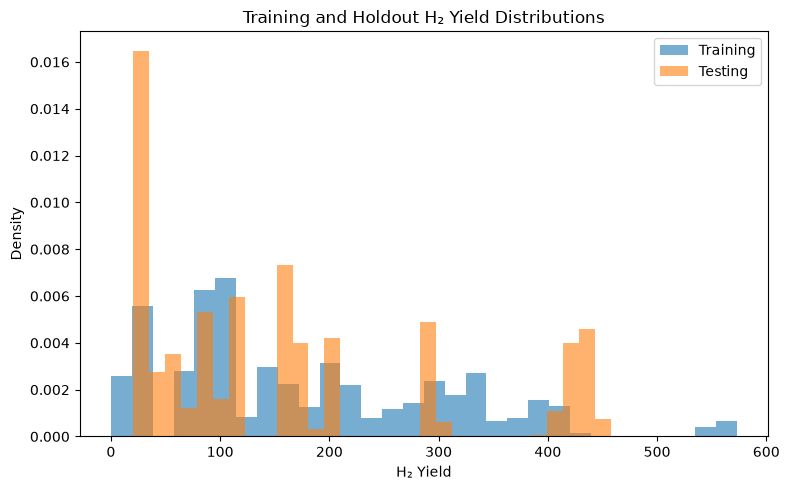

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(
    y_train,
    bins=30,
    alpha=0.6,
    label="Training",
    density=True
)

plt.hist(
    y_test,
    bins=30,
    alpha=0.6,
    label="Testing",
    density=True
)

plt.xlabel("H₂ Yield")
plt.ylabel("Density")
plt.title(
    "Training and Holdout H₂ Yield Distributions"
)

plt.legend()
plt.tight_layout()
plt.show()

## 9. Source-Level Stratified Cross-Validation Strategy

Model development and comparison will be performed exclusively on the
training partition.

Because the effective modelling basis consists of parent experimental
observations rather than 4,746 fully independent synthetic rows,
cross-validation folds are first constructed at the `source_id` level.

The 48 training source groups are stratified according to F/M ratio and
partitioned using five-fold stratified cross-validation. The resulting
source-level folds are then mapped back to the synthetic descendants.

This strategy ensures that:

- descendants of the same parent observation remain within one fold,
- no source group occurs in both model-fitting and validation partitions,
- F/M-ratio representation is distributed across validation folds as
  consistently as the limited number of parent experiments permits.

The independent holdout test set remains untouched during model comparison
and hyperparameter selection.

Model performance will be evaluated using:

- **R²** — proportion of target variance explained
- **MAE** — mean absolute prediction error
- **RMSE** — root mean squared prediction error

The effective experimental sample size remains limited to 61 parent
observations. Therefore, performance estimates are interpreted as
generalization across unseen parent experimental conditions rather than
across 6,000 independent experiments.


In [11]:
from sklearn.model_selection import StratifiedKFold

training_source_data = (
    source_level_data[
        source_level_data[GROUP_COLUMN].isin(
            train_source_set
        )
    ]
    .reset_index(drop=True)
)

source_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_splits = []

for fold_number, (
    source_train_idx,
    source_valid_idx
) in enumerate(
    source_cv.split(
        training_source_data[GROUP_COLUMN],
        training_source_data["fm_ratio"].astype(str)
    ),
    start=1
):
    fold_train_sources = set(
        training_source_data
        .iloc[source_train_idx][GROUP_COLUMN]
    )
    fold_valid_sources = set(
        training_source_data
        .iloc[source_valid_idx][GROUP_COLUMN]
    )

    row_train_idx = np.flatnonzero(
        groups_train.isin(fold_train_sources).to_numpy()
    )
    row_valid_idx = np.flatnonzero(
        groups_train.isin(fold_valid_sources).to_numpy()
    )

    cv_splits.append((row_train_idx, row_valid_idx))

cv_scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

print("=" * 70)
print("SOURCE-LEVEL STRATIFIED CROSS-VALIDATION")
print("=" * 70)

print("Number of CV folds:", len(cv_splits))
print("Training source groups:", groups_train.nunique())

print(
    "\nValidation source-group distribution "
    "by F/M ratio:"
)

for fold_number, (_, valid_idx) in enumerate(
    cv_splits,
    start=1
):
    fold_groups = groups_train.iloc[valid_idx]
    fold_fm = X_train.iloc[valid_idx]["fm_ratio"]

    fold_audit = (
        pd.DataFrame({
            "source_id": fold_groups.to_numpy(),
            "fm_ratio": fold_fm.to_numpy()
        })
        .drop_duplicates()
        ["fm_ratio"]
        .value_counts()
        .sort_index()
    )

    print(
        f"Fold {fold_number}: "
        f"{fold_groups.nunique()} source groups"
    )
    print(fold_audit.to_dict())

print("\nHoldout test set remains untouched.")


SOURCE-LEVEL STRATIFIED CROSS-VALIDATION
Number of CV folds: 5
Training source groups: 48

Validation source-group distribution by F/M ratio:
Fold 1: 10 source groups
{0.5: 2, 1.0: 2, 1.5: 1, 2.0: 2, 2.5: 1, 3.0: 2}
Fold 2: 10 source groups
{0.5: 2, 1.0: 2, 1.5: 1, 2.0: 2, 2.5: 1, 3.0: 2}
Fold 3: 10 source groups
{0.5: 2, 1.0: 1, 1.5: 2, 2.0: 1, 2.5: 2, 3.0: 2}
Fold 4: 9 source groups
{0.5: 1, 1.0: 2, 1.5: 2, 2.0: 1, 2.5: 2, 3.0: 1}
Fold 5: 9 source groups
{0.5: 1, 1.0: 2, 1.5: 1, 2.0: 2, 2.5: 2, 3.0: 1}

Holdout test set remains untouched.


## 10. Define Candidate Regression Models

A set of baseline, linear, regularized, and ensemble regression algorithms is
evaluated using the source-level stratified cross-validation folds.

The candidate models include:

- Dummy Regressor
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest
- Extra Trees
- Gradient Boosting

Standardization is applied to linear and regularized regression models through
scikit-learn pipelines. Tree-based ensemble models are evaluated without
feature scaling.

The independent holdout test dataset remains untouched during model
comparison.

In [12]:
models = {
    "Dummy Regressor": DummyRegressor(
        strategy="mean"
    ),

    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            Lasso(
                max_iter=10000,
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

print("=" * 70)
print("CANDIDATE REGRESSION MODELS")
print("=" * 70)

for i, model_name in enumerate(
    models.keys(),
    start=1
):
    print(f"{i:02d}. {model_name}")

print(
    f"\nTotal candidate models: "
    f"{len(models)}"
)

CANDIDATE REGRESSION MODELS
01. Dummy Regressor
02. Linear Regression
03. Ridge Regression
04. Lasso Regression
05. Random Forest
06. Extra Trees
07. Gradient Boosting

Total candidate models: 7


## 11. Cross-Validated Model Benchmarking

Each candidate regression model is evaluated using the predefined source-level
stratified cross-validation folds.

The same validation folds are used for every model to ensure a consistent and
fair comparison.

Performance is evaluated using:

- Mean R²
- Standard deviation of R²
- Mean MAE
- Standard deviation of MAE
- Mean RMSE
- Standard deviation of RMSE

The independent holdout dataset remains sealed during benchmarking.

In [13]:
benchmark_results = []

for model_name, model in models.items():

    print(
        f"Evaluating: {model_name}"
    )

    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv_splits,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=False
    )

    r2_scores = cv_results["test_r2"]

    mae_scores = (
        -cv_results["test_mae"]
    )

    rmse_scores = (
        -cv_results["test_rmse"]
    )

    benchmark_results.append({
        "Model": model_name,
        "Mean_R2": np.mean(r2_scores),
        "Std_R2": np.std(r2_scores),
        "Mean_MAE": np.mean(mae_scores),
        "Std_MAE": np.std(mae_scores),
        "Mean_RMSE": np.mean(rmse_scores),
        "Std_RMSE": np.std(rmse_scores)
    })

benchmark_df = (
    pd.DataFrame(benchmark_results)
    .sort_values(
        by="Mean_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "\nModel benchmarking complete."
)

display(benchmark_df)

Evaluating: Dummy Regressor
Evaluating: Linear Regression
Evaluating: Ridge Regression
Evaluating: Lasso Regression
Evaluating: Random Forest
Evaluating: Extra Trees
Evaluating: Gradient Boosting

Model benchmarking complete.


,Model,Mean_R2,Std_R2,Mean_MAE,Std_MAE,Mean_RMSE,Std_RMSE
0,Extra Trees,0.6515,0.2195,46.4235,14.0644,71.2519,22.6373
1,Gradient Boosting,0.6486,0.2233,47.6003,13.6339,70.7812,23.2766
2,Random Forest,0.5181,0.3663,51.9409,21.7020,81.4365,32.2983
3,Lasso Regression,0.5175,0.1297,70.4642,15.2164,87.3193,17.9709
4,Ridge Regression,0.5036,0.1098,72.1214,13.3773,88.8047,16.2876
5,Linear Regression,0.5032,0.1093,72.1507,13.3465,88.8469,16.2329
6,Dummy Regressor,-0.0012,0.0014,106.2687,8.3294,126.3629,14.4331


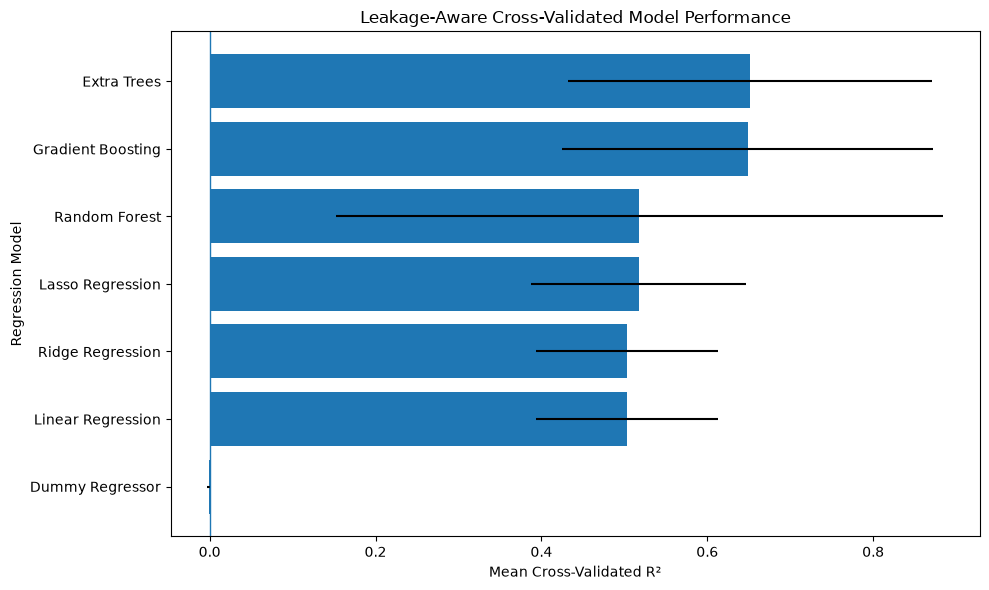

In [14]:
plt.figure(figsize=(10, 6))

plot_data = benchmark_df.sort_values(
    by="Mean_R2",
    ascending=True
)

plt.barh(
    plot_data["Model"],
    plot_data["Mean_R2"],
    xerr=plot_data["Std_R2"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel("Mean Cross-Validated R²")
plt.ylabel("Regression Model")

plt.title(
    "Leakage-Aware Cross-Validated Model Performance"
)

plt.tight_layout()
plt.show()

## 12. Fold-Level Performance Analysis

Mean cross-validation metrics summarize overall model performance but may hide
substantial differences between validation folds.

Because the effective modelling dataset contains only 48 parent experimental
groups in the development partition, model performance may vary depending on
which experimental conditions are assigned to a validation fold.

The three strongest nonlinear ensemble models are therefore examined at the
individual fold level.

This analysis evaluates:

- variation in validation R² across folds,
- consistency of MAE and RMSE,
- unusually weak validation folds, and
- differences in stability between ensemble algorithms.

In [15]:
top_model_names = [
    "Extra Trees",
    "Gradient Boosting",
    "Random Forest"
]

fold_results = []

for model_name in top_model_names:

    model = models[model_name]

    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv_splits,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=True
    )

    for fold_number in range(
        len(cv_splits)
    ):

        fold_results.append({
            "Model": model_name,
            "Fold": fold_number + 1,
            "Train_R2": (
                cv_results["train_r2"][fold_number]
            ),
            "Validation_R2": (
                cv_results["test_r2"][fold_number]
            ),
            "Validation_MAE": (
                -cv_results["test_mae"][fold_number]
            ),
            "Validation_RMSE": (
                -cv_results["test_rmse"][fold_number]
            )
        })

fold_results_df = pd.DataFrame(
    fold_results
)

display(fold_results_df)

,Model,Fold,Train_R2,Validation_R2,Validation_MAE,Validation_RMSE
0,Extra Trees,1,1.0000,0.6632,54.9661,71.7605
1,Extra Trees,2,1.0000,0.8941,27.3820,36.1120
2,Extra Trees,3,1.0000,0.7588,41.9006,75.4962
3,Extra Trees,4,1.0000,0.6996,39.4396,65.8607
4,Extra Trees,5,1.0000,0.2416,68.4293,107.0303
5,Gradient Boosting,1,0.9985,0.3587,70.2200,99.0197
6,Gradient Boosting,2,0.9983,0.8222,39.1515,46.7867
7,Gradient Boosting,3,0.9978,0.8022,39.2128,68.3741
8,Gradient Boosting,4,0.9977,0.8654,33.3222,44.0909
9,Gradient Boosting,5,0.9985,0.3945,56.0952,95.6345


## 13. Training–Validation Performance Gap

Tree-based ensemble models can closely fit synthetic descendants within the
training partition while performing less consistently on unseen parent
experimental observations.

To assess this behaviour, the difference between training and validation R² is
calculated for each fold.

A large positive performance gap may indicate that the model is learning
fine-scale patterns specific to the available parent experiments rather than
relationships that consistently generalize to unseen experimental conditions.

The performance gap is therefore used as a diagnostic indicator of potential
overfitting.

In [16]:
fold_results_df["R2_Gap"] = (
    fold_results_df["Train_R2"]
    - fold_results_df["Validation_R2"]
)

gap_summary = (
    fold_results_df
    .groupby("Model")
    .agg(
        Mean_Train_R2=(
            "Train_R2",
            "mean"
        ),
        Mean_Validation_R2=(
            "Validation_R2",
            "mean"
        ),
        Mean_R2_Gap=(
            "R2_Gap",
            "mean"
        ),
        Max_R2_Gap=(
            "R2_Gap",
            "max"
        ),
        Min_Validation_R2=(
            "Validation_R2",
            "min"
        ),
        Max_Validation_R2=(
            "Validation_R2",
            "max"
        )
    )
    .sort_values(
        by="Mean_Validation_R2",
        ascending=False
    )
)

print("=" * 70)
print("TRAINING–VALIDATION PERFORMANCE GAP")
print("=" * 70)

display(gap_summary)

TRAINING–VALIDATION PERFORMANCE GAP


,Mean_Train_R2,Mean_Validation_R2,Mean_R2_Gap,Max_R2_Gap,Min_Validation_R2,Max_Validation_R2
Model,,,,,,
Extra Trees,1.0000,0.6515,0.3485,0.7584,0.2416,0.8941
Gradient Boosting,0.9981,0.6486,0.3495,0.6398,0.3587,0.8654
Random Forest,0.9997,0.5181,0.4816,1.0876,-0.0880,0.8377


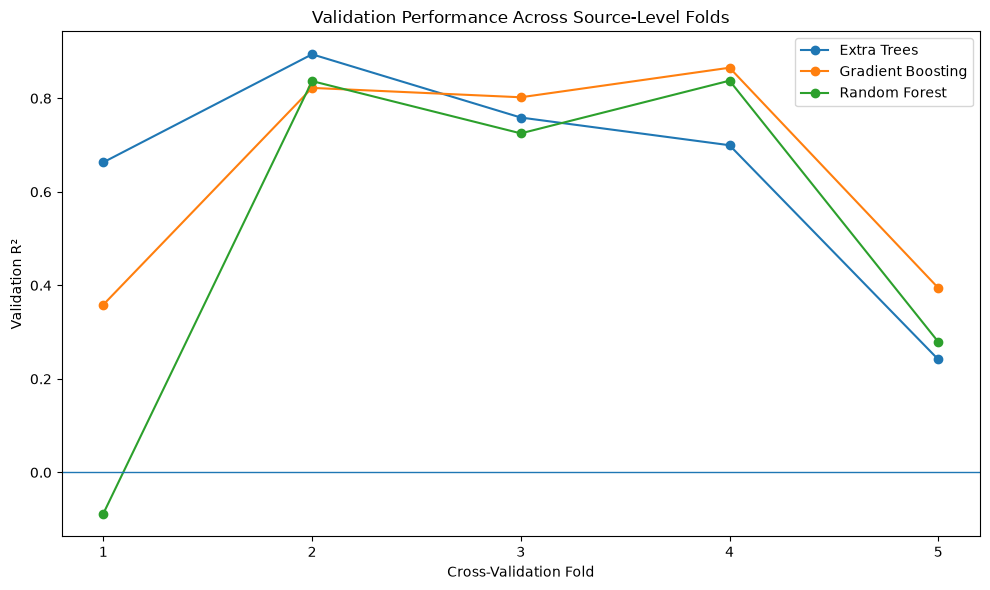

In [17]:
plt.figure(figsize=(10, 6))

for model_name in top_model_names:

    model_data = fold_results_df[
        fold_results_df["Model"]
        == model_name
    ]

    plt.plot(
        model_data["Fold"],
        model_data["Validation_R2"],
        marker="o",
        label=model_name
    )

plt.axhline(
    y=0,
    linewidth=1
)

plt.xlabel("Cross-Validation Fold")
plt.ylabel("Validation R²")

plt.title(
    "Validation Performance Across Source-Level Folds"
)

plt.xticks(
    range(
        1,
        len(cv_splits) + 1
    )
)

plt.legend()
plt.tight_layout()
plt.show()

## 14. Selection of Models for Hyperparameter Optimization

The initial benchmarking and fold-level diagnostic analysis identified Extra
Trees and Gradient Boosting as the strongest candidate models.

Although Extra Trees achieved the highest mean validation R², its training R²
was consistently equal to 1.00, indicating complete fitting of the training
data.

Gradient Boosting produced a nearly identical mean validation R² and slightly
lower validation RMSE. However, its training performance was also substantially
higher than its validation performance.

Random Forest was excluded from further optimization because it demonstrated
the largest training-validation gap and produced negative validation R² in one
source-level fold.

Therefore, Extra Trees and Gradient Boosting are retained for constrained
hyperparameter optimization.

The optimization strategy emphasizes model regularization and generalization
to unseen parent experimental observations rather than maximizing training
performance.

## 15. Constrained Hyperparameter Search

Randomized hyperparameter search is performed separately for Extra Trees and
Gradient Boosting.

The search spaces intentionally include parameters that restrict model
complexity.

For Extra Trees, regularization is introduced through:

- maximum tree depth,
- minimum samples required at leaf nodes, and
- the proportion of predictors considered at each split.

For Gradient Boosting, model complexity is controlled through:

- number of boosting estimators,
- learning rate,
- maximum tree depth, and
- minimum samples required at leaf nodes.

The predefined source-level stratified cross-validation folds are used during
optimization.

The independent holdout test dataset remains untouched.

In [18]:
from sklearn.model_selection import RandomizedSearchCV

extra_trees_param_distributions = {
    "n_estimators": [
        200,
        300,
        500
    ],
    "max_depth": [
        4,
        6,
        8,
        10,
        None
    ],
    "min_samples_leaf": [
        2,
        5,
        10,
        20,
        40
    ],
    "max_features": [
        0.5,
        0.75,
        1.0
    ]
}

gradient_boosting_param_distributions = {
    "n_estimators": [
        50,
        100,
        150,
        200,
        300
    ],
    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],
    "max_depth": [
        1,
        2,
        3,
        4
    ],
    "min_samples_leaf": [
        5,
        10,
        20,
        40
    ]
}

print(
    "Hyperparameter search spaces defined."
)

Hyperparameter search spaces defined.


In [19]:
extra_trees_search = RandomizedSearchCV(
    estimator=ExtraTreesRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=(
        extra_trees_param_distributions
    ),
    n_iter=40,
    scoring="r2",
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

print(
    "Optimizing Extra Trees..."
)

extra_trees_search.fit(
    X_train,
    y_train
)

print(
    "\nExtra Trees optimization complete."
)

print(
    "\nBest CV R²:",
    round(
        extra_trees_search.best_score_,
        4
    )
)

print(
    "\nBest parameters:"
)

for parameter, value in (
    extra_trees_search
    .best_params_
    .items()
):
    print(
        f"{parameter}: {value}"
    )

Optimizing Extra Trees...

Extra Trees optimization complete.

Best CV R²: 0.6728

Best parameters:
n_estimators: 200
min_samples_leaf: 2
max_features: 1.0
max_depth: 4


In [20]:
gradient_boosting_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    param_distributions=(
        gradient_boosting_param_distributions
    ),
    n_iter=40,
    scoring="r2",
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

print(
    "Optimizing Gradient Boosting..."
)

gradient_boosting_search.fit(
    X_train,
    y_train
)

print(
    "\nGradient Boosting optimization complete."
)

print(
    "\nBest CV R²:",
    round(
        gradient_boosting_search.best_score_,
        4
    )
)

print(
    "\nBest parameters:"
)

for parameter, value in (
    gradient_boosting_search
    .best_params_
    .items()
):
    print(
        f"{parameter}: {value}"
    )

Optimizing Gradient Boosting...

Gradient Boosting optimization complete.

Best CV R²: 0.6671

Best parameters:
n_estimators: 200
min_samples_leaf: 20
max_depth: 2
learning_rate: 0.01


## 16. Tuned Model Cross-Validation Comparison

The optimized Extra Trees and Gradient Boosting models are reevaluated using
the same source-level stratified cross-validation folds.

Both training and validation R² are calculated to determine whether
hyperparameter optimization reduced the training-validation performance gap.

The tuned models are compared using:

- mean training R²,
- mean validation R²,
- standard deviation of validation R²,
- mean validation MAE,
- mean validation RMSE, and
- mean training-validation R² gap.

The model demonstrating the strongest balance between predictive performance
and generalization stability will be selected for final holdout evaluation.

In [21]:
tuned_models = {
    "Tuned Extra Trees": (
        extra_trees_search.best_estimator_
    ),
    "Tuned Gradient Boosting": (
        gradient_boosting_search.best_estimator_
    )
}

tuned_results = []

for model_name, model in tuned_models.items():

    cv_results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv_splits,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=True
    )

    train_r2 = cv_results["train_r2"]
    validation_r2 = cv_results["test_r2"]

    tuned_results.append({
        "Model": model_name,
        "Mean_Train_R2": np.mean(train_r2),
        "Mean_Validation_R2": np.mean(
            validation_r2
        ),
        "Std_Validation_R2": np.std(
            validation_r2
        ),
        "Mean_MAE": np.mean(
            -cv_results["test_mae"]
        ),
        "Mean_RMSE": np.mean(
            -cv_results["test_rmse"]
        ),
        "Mean_R2_Gap": np.mean(
            train_r2 - validation_r2
        )
    })

tuned_results_df = (
    pd.DataFrame(tuned_results)
    .sort_values(
        by="Mean_Validation_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("TUNED MODEL COMPARISON")
print("=" * 70)

display(tuned_results_df)

TUNED MODEL COMPARISON


,Model,Mean_Train_R2,Mean_Validation_R2,Std_Validation_R2,Mean_MAE,Mean_RMSE,Mean_R2_Gap
0,Tuned Extra Trees,0.9350,0.6728,0.1652,47.3694,70.3089,0.2623
1,Tuned Gradient Boosting,0.8781,0.6671,0.1182,50.3885,71.8983,0.2110


## 17. Final Holdout Evaluation

Following leakage-aware model benchmarking and constrained hyperparameter
optimization, the two tuned candidate models are evaluated on the independent
holdout dataset.

The holdout partition contains synthetic descendants derived exclusively from
13 parent experimental observations that were not used during:

- model benchmarking,
- cross-validation,
- model selection, or
- hyperparameter optimization.

Both tuned models are evaluated on the same holdout partition using:

- R²,
- mean absolute error (MAE), and
- root mean squared error (RMSE).

The holdout results provide a final comparison of model generalization to
unseen parent experimental conditions.

Because synthetic descendants originating from the same parent observation are
correlated, row-level holdout metrics are interpreted cautiously and are not
treated as evidence from 1,000+ independent experiments.

In [22]:
holdout_results = []
holdout_predictions = {}

for model_name, model in tuned_models.items():

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    holdout_predictions[
        model_name
    ] = y_pred

    holdout_results.append({
        "Model": model_name,
        "Holdout_R2": r2_score(
            y_test,
            y_pred
        ),
        "Holdout_MAE": mean_absolute_error(
            y_test,
            y_pred
        ),
        "Holdout_RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                y_pred
            )
        )
    })

holdout_results_df = (
    pd.DataFrame(holdout_results)
    .sort_values(
        by="Holdout_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("FINAL HOLDOUT MODEL COMPARISON")
print("=" * 70)

display(holdout_results_df)

FINAL HOLDOUT MODEL COMPARISON


,Model,Holdout_R2,Holdout_MAE,Holdout_RMSE
0,Tuned Extra Trees,0.7253,46.3224,72.0002
1,Tuned Gradient Boosting,0.6866,55.8717,76.9097


## 18. Parent-Level Holdout Performance

Row-level holdout metrics evaluate predictions across all synthetic descendants
in the independent holdout partition.

However, the effective independent units are the 13 parent experimental
observations represented by `source_id`.

To provide a complementary group-level evaluation, observed and predicted H₂
yield values are averaged within each parent experimental group.

Performance metrics are then calculated across the 13 parent-level mean
observations.

This analysis reduces the influence of unequal synthetic descendant counts and
provides a more conservative assessment of generalization across unseen parent
experimental conditions.

In [23]:
parent_level_results = []

for model_name, y_pred in (
    holdout_predictions.items()
):

    parent_predictions = pd.DataFrame({
        "source_id": (
            groups_test.to_numpy()
        ),
        "Observed_H2": (
            y_test.to_numpy()
        ),
        "Predicted_H2": y_pred
    })

    parent_predictions = (
        parent_predictions
        .groupby(
            "source_id",
            as_index=False
        )
        .agg(
            Observed_H2=(
                "Observed_H2",
                "mean"
            ),
            Predicted_H2=(
                "Predicted_H2",
                "mean"
            )
        )
    )

    parent_level_results.append({
        "Model": model_name,
        "Parent_R2": r2_score(
            parent_predictions["Observed_H2"],
            parent_predictions["Predicted_H2"]
        ),
        "Parent_MAE": mean_absolute_error(
            parent_predictions["Observed_H2"],
            parent_predictions["Predicted_H2"]
        ),
        "Parent_RMSE": np.sqrt(
            mean_squared_error(
                parent_predictions["Observed_H2"],
                parent_predictions["Predicted_H2"]
            )
        )
    })

parent_level_results_df = (
    pd.DataFrame(
        parent_level_results
    )
    .sort_values(
        by="Parent_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("PARENT-LEVEL HOLDOUT PERFORMANCE")
print("=" * 70)

display(parent_level_results_df)

PARENT-LEVEL HOLDOUT PERFORMANCE


,Model,Parent_R2,Parent_MAE,Parent_RMSE
0,Tuned Extra Trees,0.7217,47.6331,73.3929
1,Tuned Gradient Boosting,0.6842,57.4512,78.1767


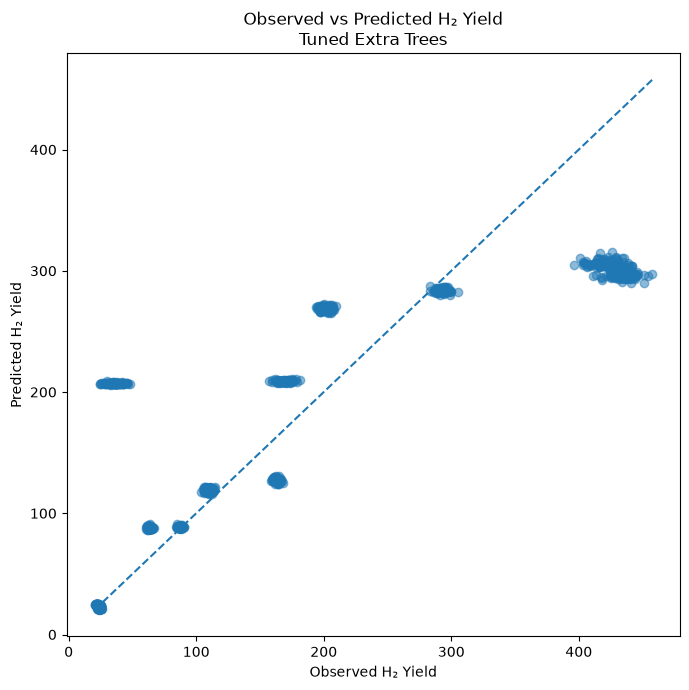

Selected model: Tuned Extra Trees


In [24]:
best_model_name = (
    parent_level_results_df
    .iloc[0]["Model"]
)

best_model = tuned_models[
    best_model_name
]

best_predictions = holdout_predictions[
    best_model_name
]

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plot_min = min(
    y_test.min(),
    best_predictions.min()
)

plot_max = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--"
)

plt.xlabel("Observed H₂ Yield")
plt.ylabel("Predicted H₂ Yield")

plt.title(
    f"Observed vs Predicted H₂ Yield\n"
    f"{best_model_name}"
)

plt.tight_layout()
plt.show()

print(
    "Selected model:",
    best_model_name
)

## 19. Original Experimental Holdout Evaluation

The synthetic holdout analysis evaluates model performance on Bootstrap-Jitter
descendants derived from 13 unseen parent experimental observations.

A stronger validation is obtained by evaluating the selected model directly on
the corresponding original experimental observations.

During synthetic data generation, each `source_id` was recorded from the true
row index of the sampled parent experimental observation. Therefore,
`EXP_001` corresponds to the first row of the reference experimental dataset,
`EXP_002` to the second row, and so forth.

The 13 source identifiers reserved during the leakage-aware holdout split are
mapped back to their original experimental observations.

The selected Extra Trees model is then evaluated directly on these 13 original
experiments.

These observations were excluded at the parent-source level from model
training, cross-validation, model selection, and hyperparameter optimization.

In [25]:
REFERENCE_DATA_PATH = Path(
    r"D:\Data Science Projects\Hydrogen yield predictor"
    r"\data\reference_experimental_data.csv"
)

experimental_df = pd.read_csv(
    REFERENCE_DATA_PATH
)

experimental_df = (
    experimental_df[
        feature_columns + [TARGET]
    ]
    .copy()
    .reset_index(drop=True)
)

experimental_df["source_id"] = [
    f"EXP_{index + 1:03d}"
    for index in experimental_df.index
]

print("=" * 70)
print("REFERENCE EXPERIMENTAL DATA")
print("=" * 70)

print(
    "Experimental observations:",
    len(experimental_df)
)

print(
    "Unique source IDs:",
    experimental_df["source_id"].nunique()
)

experimental_df.head()

REFERENCE EXPERIMENTAL DATA
Experimental observations: 61
Unique source IDs: 61


,substrate_mc,substrate_ts,substrate_vs,substrate_fs,inoculum_mc,inoculum_ts,inoculum_vs,inoculum_fs,scod,tcod,scod_tcod_ratio,trs,lignin,hmf,fm_ratio,h2_yield,source_id
0,5.2100,94.7900,89.2200,10.7800,90.1100,9.8900,90.1100,9.8900,6000,11500,0.5200,1.4400,25.4200,42.5500,0.5000,22.2200,EXP_001
1,5.6400,94.3600,87.2300,12.7700,92.3300,7.6700,86.4000,13.6000,6400,12000,0.5300,6.8200,23.2100,689.4900,0.5000,20.4000,EXP_002
2,5.6100,94.3900,88.2600,11.7400,95.1200,4.8800,87.2600,12.7400,5800,8900,0.6500,5.7400,23.0000,425.1900,0.5000,26.4500,EXP_003
3,5.2600,94.7400,78.6400,21.3600,94.7000,5.3000,92.3300,7.6700,5800,9000,0.6400,22.1600,28.9100,189.3500,0.5000,24.2200,EXP_004
4,5.9400,94.0600,78.4100,21.5900,93.7800,6.2200,84.7700,15.2300,6000,11200,0.5400,22.2000,20.2300,0.0000,0.5000,19.6500,EXP_005


## 20. Recover Original Holdout Experiments

The source identifiers assigned to the independent holdout partition are used
to recover the corresponding original experimental observations.

The recovered dataset must contain exactly the same 13 parent experimental
groups represented in the synthetic holdout partition.

Source-ID overlap with the model-development groups is checked again before
prediction.

In [26]:
original_holdout_df = (
    experimental_df[
        experimental_df["source_id"].isin(
            test_source_set
        )
    ]
    .copy()
    .sort_values("source_id")
    .reset_index(drop=True)
)

original_holdout_sources = set(
    original_holdout_df["source_id"]
)

original_training_sources = set(
    train_source_set
)

source_overlap = (
    original_holdout_sources
    .intersection(original_training_sources)
)

print("=" * 70)
print("ORIGINAL EXPERIMENTAL HOLDOUT RECOVERY")
print("=" * 70)

print(
    "Recovered original experiments:",
    len(original_holdout_df)
)

print(
    "Recovered source groups:",
    len(original_holdout_sources)
)

print(
    "Training-source overlap:",
    len(source_overlap)
)

print(
    "\nF/M ratio distribution:"
)

print(
    original_holdout_df["fm_ratio"]
    .value_counts()
    .sort_index()
)

assert len(original_holdout_df) == len(
    test_source_set
)

assert len(source_overlap) == 0

print(
    "\nPASS: Original experimental holdout "
    "successfully recovered."
)

ORIGINAL EXPERIMENTAL HOLDOUT RECOVERY
Recovered original experiments: 13
Recovered source groups: 13
Training-source overlap: 0

F/M ratio distribution:
fm_ratio
0.5000    3
1.0000    2
1.5000    2
2.0000    2
2.5000    2
3.0000    2
Name: count, dtype: int64

PASS: Original experimental holdout successfully recovered.


## 21. Final Evaluation on Unseen Original Experiments

The selected tuned Extra Trees model is evaluated directly on the recovered
original experimental holdout observations.

Unlike the synthetic row-level evaluation, each row in this analysis
represents one actual parent experimental observation.

The resulting metrics therefore provide the most conservative and practically
meaningful estimate of model performance available within the current
experimental dataset.

Because the final evaluation contains only 13 observations, the resulting
metrics should still be interpreted cautiously.

In [27]:
X_original_holdout = original_holdout_df[
    feature_columns
].copy()

y_original_holdout = original_holdout_df[
    TARGET
].copy()

original_holdout_predictions = (
    best_model.predict(
        X_original_holdout
    )
)

original_holdout_r2 = r2_score(
    y_original_holdout,
    original_holdout_predictions
)

original_holdout_mae = mean_absolute_error(
    y_original_holdout,
    original_holdout_predictions
)

original_holdout_rmse = np.sqrt(
    mean_squared_error(
        y_original_holdout,
        original_holdout_predictions
    )
)

print("=" * 70)
print("ORIGINAL EXPERIMENTAL HOLDOUT PERFORMANCE")
print("=" * 70)

print(
    f"R²   : {original_holdout_r2:.4f}"
)

print(
    f"MAE  : {original_holdout_mae:.4f}"
)

print(
    f"RMSE : {original_holdout_rmse:.4f}"
)

print(
    f"\nNumber of unseen original experiments: "
    f"{len(y_original_holdout)}"
)

ORIGINAL EXPERIMENTAL HOLDOUT PERFORMANCE
R²   : 0.7201
MAE  : 47.8586
RMSE : 73.5473

Number of unseen original experiments: 13


In [28]:
original_prediction_df = pd.DataFrame({
    "source_id": original_holdout_df["source_id"],
    "fm_ratio": original_holdout_df["fm_ratio"],
    "Observed_H2": y_original_holdout,
    "Predicted_H2": original_holdout_predictions
})

original_prediction_df["Absolute_Error"] = (
    original_prediction_df["Observed_H2"]
    - original_prediction_df["Predicted_H2"]
).abs()

display(original_prediction_df)

,source_id,fm_ratio,Observed_H2,Predicted_H2,Absolute_Error
0,EXP_004,0.5000,24.2200,23.0591,1.1609
1,EXP_006,0.5000,22.3100,24.2515,1.9415
2,EXP_010,0.5000,24.2100,21.2271,2.9829
3,EXP_020,1.0000,63.9000,87.9213,24.0213
4,EXP_022,1.0000,87.2600,88.5988,1.3388
5,EXP_027,1.5000,109.5200,119.8346,10.3146
6,EXP_028,1.5000,163.2000,127.8002,35.3998
7,EXP_034,2.0000,435.5500,294.3135,141.2365
8,EXP_041,2.0000,419.8700,306.4918,113.3782
9,EXP_046,2.5000,293.6100,282.4105,11.1995


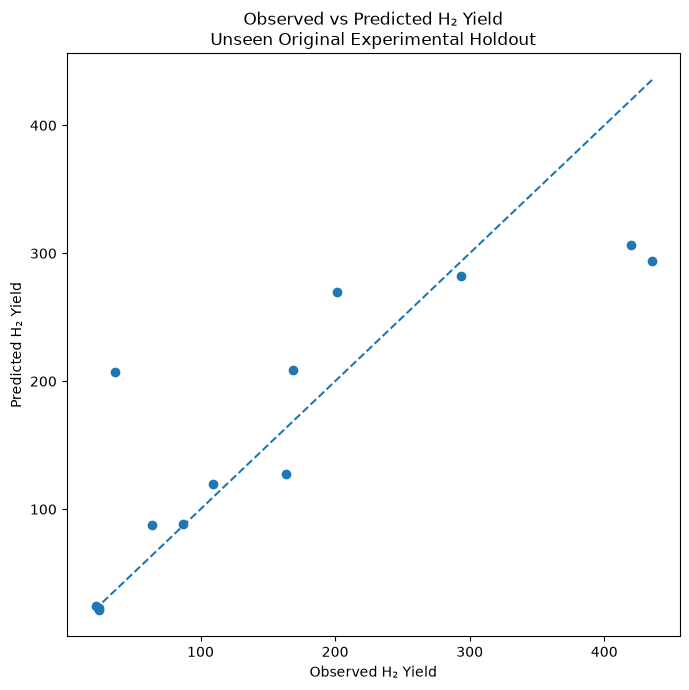

In [29]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_original_holdout,
    original_holdout_predictions
)

plot_min = min(
    y_original_holdout.min(),
    original_holdout_predictions.min()
)

plot_max = max(
    y_original_holdout.max(),
    original_holdout_predictions.max()
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--"
)

plt.xlabel("Observed H₂ Yield")
plt.ylabel("Predicted H₂ Yield")

plt.title(
    "Observed vs Predicted H₂ Yield\n"
    "Unseen Original Experimental Holdout"
)

plt.tight_layout()
plt.show()

## 22. Prediction Error Analysis by F/M Ratio

The original experimental holdout results demonstrate consistent overall
predictive performance relative to cross-validation and synthetic holdout
evaluation.

However, individual prediction errors vary substantially across experimental
conditions.

Prediction residuals are therefore examined according to F/M ratio to identify
systematic regions of underprediction or overprediction.

The residual is defined as:

**Residual = Observed H₂ Yield − Predicted H₂ Yield**

Therefore:

- a positive residual indicates model underprediction,
- a negative residual indicates model overprediction.

This analysis is particularly important because model performance may differ
across the F/M operating range even when overall R² remains satisfactory.

In [30]:
original_prediction_df["Residual"] = (
    original_prediction_df["Observed_H2"]
    - original_prediction_df["Predicted_H2"]
)

fm_error_analysis = (
    original_prediction_df
    .groupby("fm_ratio")
    .agg(
        Number_of_Experiments=(
            "source_id",
            "count"
        ),
        Mean_Observed_H2=(
            "Observed_H2",
            "mean"
        ),
        Mean_Predicted_H2=(
            "Predicted_H2",
            "mean"
        ),
        Mean_Residual=(
            "Residual",
            "mean"
        ),
        Mean_Absolute_Error=(
            "Absolute_Error",
            "mean"
        ),
        Maximum_Absolute_Error=(
            "Absolute_Error",
            "max"
        )
    )
)

print("=" * 70)
print("PREDICTION ERROR BY F/M RATIO")
print("=" * 70)

display(fm_error_analysis)

PREDICTION ERROR BY F/M RATIO


,Number_of_Experiments,Mean_Observed_H2,Mean_Predicted_H2,Mean_Residual,Mean_Absolute_Error,Maximum_Absolute_Error
fm_ratio,,,,,,
0.5000,3,23.5800,22.8459,0.7341,2.0284,2.9829
1.0000,2,75.5800,88.2601,-12.6801,12.6801,24.0213
1.5000,2,136.3600,123.8174,12.5426,22.8572,35.3998
2.0000,2,427.7100,300.4027,127.3073,127.3073,141.2365
2.5000,2,247.3650,275.9371,-28.5721,39.7715,68.3436
3.0000,2,102.4800,207.9023,-105.4223,105.4223,170.7712


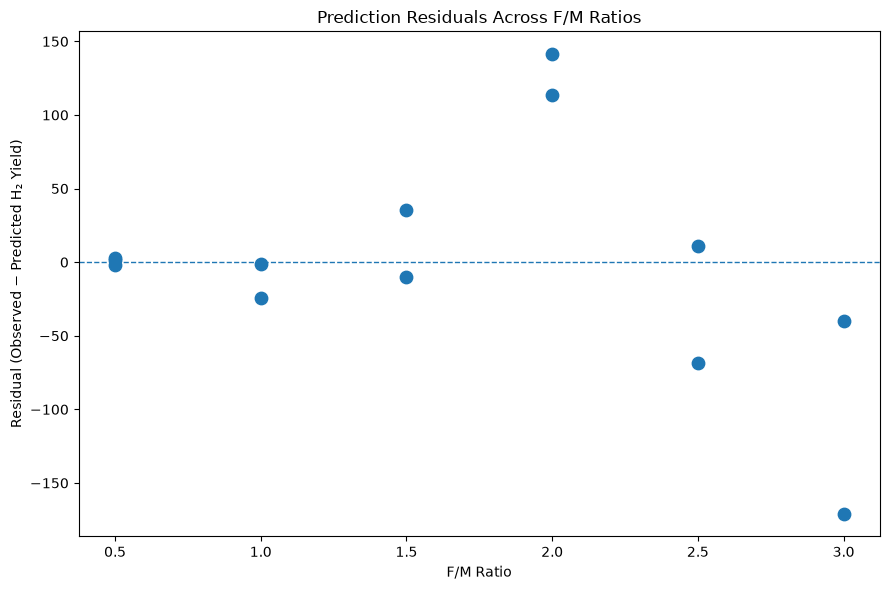

In [31]:
plt.figure(figsize=(9, 6))

plt.scatter(
    original_prediction_df["fm_ratio"],
    original_prediction_df["Residual"],
    s=80
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("F/M Ratio")
plt.ylabel("Residual (Observed − Predicted H₂ Yield)")

plt.title(
    "Prediction Residuals Across F/M Ratios"
)

plt.tight_layout()
plt.show()

## 23. Identification of High-Error Experimental Conditions

The experimental observations with the largest absolute prediction errors are
examined individually.

Large errors may indicate:

- experimental conditions that are poorly represented by the training parent
  observations,
- strong nonlinear process behaviour,
- interactions not fully captured by the selected model, or
- biological variability that cannot be explained by the available predictor
  variables.

These observations are retained in the evaluation dataset and are not removed
as model outliers.

Removing difficult observations after holdout evaluation would produce an
optimistically biased estimate of predictive performance.

In [32]:
high_error_threshold = (
    original_prediction_df[
        "Absolute_Error"
    ]
    .quantile(0.75)
)

high_error_experiments = (
    original_prediction_df[
        original_prediction_df[
            "Absolute_Error"
        ] >= high_error_threshold
    ]
    .sort_values(
        by="Absolute_Error",
        ascending=False
    )
)

print("=" * 70)
print("HIGH-ERROR ORIGINAL HOLDOUT EXPERIMENTS")
print("=" * 70)

print(
    f"75th percentile absolute-error threshold: "
    f"{high_error_threshold:.4f}"
)

display(high_error_experiments)

HIGH-ERROR ORIGINAL HOLDOUT EXPERIMENTS
75th percentile absolute-error threshold: 68.3436


,source_id,fm_ratio,Observed_H2,Predicted_H2,Absolute_Error,Residual
12,EXP_060,3.0000,36.3300,207.1012,170.7712,-170.7712
7,EXP_034,2.0000,435.5500,294.3135,141.2365,141.2365
8,EXP_041,2.0000,419.8700,306.4918,113.3782,113.3782
10,EXP_050,2.5000,201.1200,269.4636,68.3436,-68.3436


## 24. Model-Based Feature Importance

The selected tuned Extra Trees model provides impurity-based feature importance
scores.

These scores quantify the relative contribution of each predictor to reducing
prediction error within the fitted tree ensemble.

Feature importance is used as an exploratory model-interpretation tool and
should not be interpreted as evidence of causality.

Because correlated predictors may share or redistribute importance, the
impurity-based results will subsequently be compared with permutation
importance.

In [33]:
feature_importance_df = (
    pd.DataFrame({
        "Feature": feature_columns,
        "Importance": best_model.feature_importances_
    })
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("EXTRA TREES FEATURE IMPORTANCE")
print("=" * 70)

display(feature_importance_df)

EXTRA TREES FEATURE IMPORTANCE


,Feature,Importance
0,fm_ratio,0.6659
1,lignin,0.1167
2,inoculum_vs,0.0609
3,inoculum_fs,0.0503
4,substrate_vs,0.0197
5,hmf,0.0181
6,substrate_mc,0.0150
7,substrate_ts,0.0119
8,substrate_fs,0.0097
9,inoculum_ts,0.0095


## 25. Permutation Feature Importance

Impurity-based feature importance may overstate the contribution of variables
frequently used for tree splitting and may distribute importance unevenly
among correlated predictors.

Permutation importance provides a complementary model-interpretation approach.

Each predictor is independently shuffled in the original experimental holdout
dataset while all other variables remain unchanged. The resulting reduction
in model R² represents the loss of predictive performance associated with
disrupting that predictor.

A larger decrease in R² indicates greater dependence of the fitted model on
the corresponding variable.

Permutation importance is evaluated on the unseen original experimental
holdout observations rather than on the model-training dataset.

In [34]:
permutation_results = permutation_importance(
    estimator=best_model,
    X=X_original_holdout,
    y=y_original_holdout,
    scoring="r2",
    n_repeats=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importance_df = (
    pd.DataFrame({
        "Feature": feature_columns,
        "Mean_Importance": (
            permutation_results.importances_mean
        ),
        "Std_Importance": (
            permutation_results.importances_std
        )
    })
    .sort_values(
        by="Mean_Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("PERMUTATION FEATURE IMPORTANCE")
print("=" * 70)

display(permutation_importance_df)

PERMUTATION FEATURE IMPORTANCE


,Feature,Mean_Importance,Std_Importance
0,fm_ratio,0.9814,0.3252
1,lignin,0.0349,0.0275
2,inoculum_vs,0.0069,0.0059
3,inoculum_fs,0.0045,0.0033
4,hmf,0.0040,0.0130
5,tcod,0.0030,0.0022
6,substrate_mc,0.0029,0.0043
7,substrate_ts,0.0022,0.0034
8,inoculum_ts,0.0011,0.0026
9,scod,0.0010,0.0011


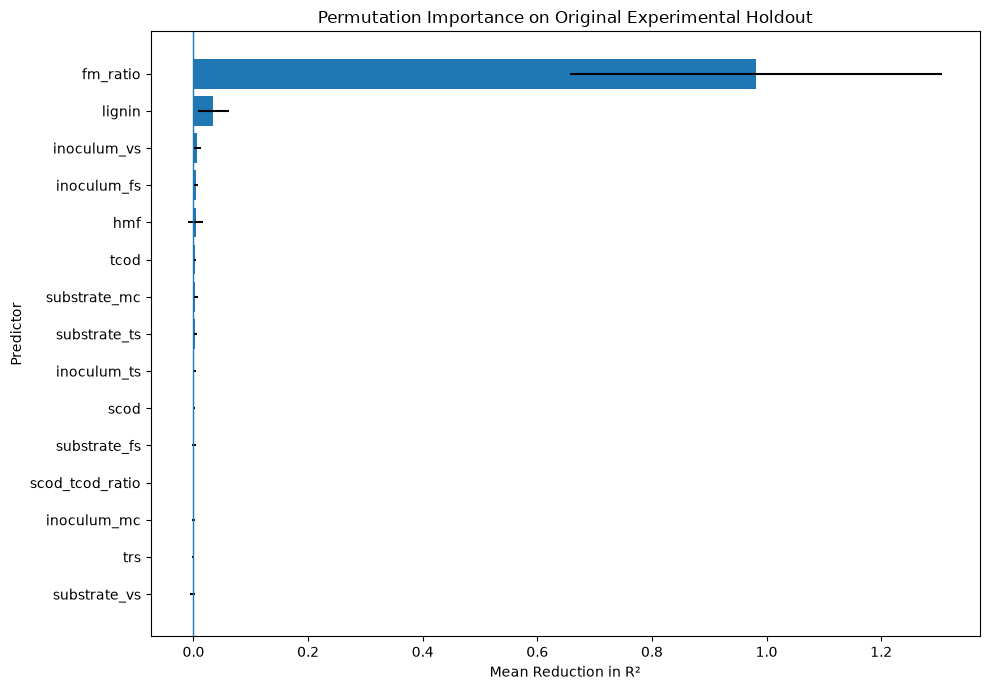

In [35]:
plt.figure(figsize=(10, 7))

permutation_plot_data = (
    permutation_importance_df
    .sort_values(
        by="Mean_Importance",
        ascending=True
    )
)

plt.barh(
    permutation_plot_data["Feature"],
    permutation_plot_data["Mean_Importance"],
    xerr=permutation_plot_data["Std_Importance"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel("Mean Reduction in R²")
plt.ylabel("Predictor")

plt.title(
    "Permutation Importance on Original Experimental Holdout"
)

plt.tight_layout()
plt.show()

## 26. Comparison of Impurity and Permutation Importance

Impurity-based and permutation importance quantify predictor relevance using
different principles.

Impurity importance describes how frequently and effectively predictors reduce
error within the fitted tree ensemble.

Permutation importance measures the reduction in predictive performance when a
variable is disrupted in unseen experimental observations.

Agreement between the two approaches strengthens evidence that a predictor is
important to model performance.

Differences may arise because of predictor correlation, nonlinear interactions,
or the limited size of the original experimental holdout dataset.

Feature importance is interpreted as model dependence and not as evidence of
biological causality.

In [36]:
importance_comparison_df = (
    feature_importance_df
    .rename(
        columns={
            "Importance": "Impurity_Importance"
        }
    )
    .merge(
        permutation_importance_df[
            [
                "Feature",
                "Mean_Importance"
            ]
        ],
        on="Feature",
        how="left"
    )
    .rename(
        columns={
            "Mean_Importance": (
                "Permutation_Importance"
            )
        }
    )
)

print("=" * 70)
print("FEATURE IMPORTANCE METHOD COMPARISON")
print("=" * 70)

display(importance_comparison_df)

FEATURE IMPORTANCE METHOD COMPARISON


,Feature,Impurity_Importance,Permutation_Importance
0,fm_ratio,0.6659,0.9814
1,lignin,0.1167,0.0349
2,inoculum_vs,0.0609,0.0069
3,inoculum_fs,0.0503,0.0045
4,substrate_vs,0.0197,-0.0015
5,hmf,0.0181,0.0040
6,substrate_mc,0.0150,0.0029
7,substrate_ts,0.0119,0.0022
8,substrate_fs,0.0097,0.0008
9,inoculum_ts,0.0095,0.0011


## 27. F/M Ratio Dependence Sensitivity Analysis

Initial model interpretation indicates that F/M ratio is the dominant
predictor in the tuned Extra Trees model.

This result is biologically plausible because substrate-to-inoculum loading can
strongly influence dark fermentation performance. However, excessive model
dependence on F/M ratio may cause the model to learn the broad experimental
response pattern without adequately explaining variation among experiments
conducted at the same F/M ratio.

A sensitivity analysis is therefore performed by training the selected model
without `fm_ratio`.

The purpose of this analysis is diagnostic rather than model replacement.

The reduced model is evaluated using the same source-level stratified
cross-validation folds. Its performance is compared with the selected full
model to quantify the predictive contribution of F/M ratio.

In [37]:
reduced_feature_columns = [
    column
    for column in feature_columns
    if column != "fm_ratio"
]

X_train_reduced = X_train[
    reduced_feature_columns
].copy()

reduced_model = ExtraTreesRegressor(
    **extra_trees_search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

reduced_cv_results = cross_validate(
    estimator=reduced_model,
    X=X_train_reduced,
    y=y_train,
    cv=cv_splits,
    scoring=cv_scoring,
    n_jobs=-1,
    return_train_score=True
)

fm_sensitivity_results = pd.DataFrame({
    "Model": [
        "Full Model",
        "Without F/M Ratio"
    ],
    "Mean_Train_R2": [
        tuned_results_df.loc[
            tuned_results_df["Model"]
            == "Tuned Extra Trees",
            "Mean_Train_R2"
        ].iloc[0],
        np.mean(
            reduced_cv_results["train_r2"]
        )
    ],
    "Mean_Validation_R2": [
        tuned_results_df.loc[
            tuned_results_df["Model"]
            == "Tuned Extra Trees",
            "Mean_Validation_R2"
        ].iloc[0],
        np.mean(
            reduced_cv_results["test_r2"]
        )
    ],
    "Std_Validation_R2": [
        tuned_results_df.loc[
            tuned_results_df["Model"]
            == "Tuned Extra Trees",
            "Std_Validation_R2"
        ].iloc[0],
        np.std(
            reduced_cv_results["test_r2"]
        )
    ],
    "Mean_MAE": [
        tuned_results_df.loc[
            tuned_results_df["Model"]
            == "Tuned Extra Trees",
            "Mean_MAE"
        ].iloc[0],
        np.mean(
            -reduced_cv_results["test_mae"]
        )
    ],
    "Mean_RMSE": [
        tuned_results_df.loc[
            tuned_results_df["Model"]
            == "Tuned Extra Trees",
            "Mean_RMSE"
        ].iloc[0],
        np.mean(
            -reduced_cv_results["test_rmse"]
        )
    ]
})

print("=" * 70)
print("F/M RATIO DEPENDENCE SENSITIVITY ANALYSIS")
print("=" * 70)

display(fm_sensitivity_results)

F/M RATIO DEPENDENCE SENSITIVITY ANALYSIS


,Model,Mean_Train_R2,Mean_Validation_R2,Std_Validation_R2,Mean_MAE,Mean_RMSE
0,Full Model,0.9350,0.6728,0.1652,47.3694,70.3089
1,Without F/M Ratio,0.8667,0.3387,0.2536,78.7215,101.4039


## 28. F/M-Only Baseline Model

Feature-importance and sensitivity analyses demonstrate that F/M ratio is the
dominant predictor of H₂ yield.

However, high feature importance alone does not establish whether the remaining
biochemical and feedstock variables provide meaningful incremental predictive
information.

A diagnostic model is therefore developed using only `fm_ratio`.

The F/M-only model uses the same tuned Extra Trees hyperparameters and the same
source-level stratified cross-validation folds as the full predictive model.

This comparison addresses an important modelling question:

**Does the multivariable model outperform a model that learns primarily from
the broad F/M–H₂ yield relationship?**

The F/M-only model is used as a diagnostic baseline and is not considered a
replacement for the selected full model unless its predictive performance is
comparable.

In [38]:
fm_only_features = [
    "fm_ratio"
]

X_train_fm_only = X_train[
    fm_only_features
].copy()

fm_only_model = ExtraTreesRegressor(
    **extra_trees_search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

fm_only_cv_results = cross_validate(
    estimator=fm_only_model,
    X=X_train_fm_only,
    y=y_train,
    cv=cv_splits,
    scoring=cv_scoring,
    n_jobs=-1,
    return_train_score=True
)

fm_only_comparison_df = pd.DataFrame({
    "Model": [
        "Full 15-Feature Model",
        "F/M-Only Model",
        "Model Without F/M"
    ],
    "Mean_Train_R2": [
        tuned_results_df.loc[
            tuned_results_df["Model"]
            == "Tuned Extra Trees",
            "Mean_Train_R2"
        ].iloc[0],
        np.mean(
            fm_only_cv_results["train_r2"]
        ),
        np.mean(
            reduced_cv_results["train_r2"]
        )
    ],
    "Mean_Validation_R2": [
        tuned_results_df.loc[
            tuned_results_df["Model"]
            == "Tuned Extra Trees",
            "Mean_Validation_R2"
        ].iloc[0],
        np.mean(
            fm_only_cv_results["test_r2"]
        ),
        np.mean(
            reduced_cv_results["test_r2"]
        )
    ],
    "Std_Validation_R2": [
        tuned_results_df.loc[
            tuned_results_df["Model"]
            == "Tuned Extra Trees",
            "Std_Validation_R2"
        ].iloc[0],
        np.std(
            fm_only_cv_results["test_r2"]
        ),
        np.std(
            reduced_cv_results["test_r2"]
        )
    ],
    "Mean_MAE": [
        tuned_results_df.loc[
            tuned_results_df["Model"]
            == "Tuned Extra Trees",
            "Mean_MAE"
        ].iloc[0],
        np.mean(
            -fm_only_cv_results["test_mae"]
        ),
        np.mean(
            -reduced_cv_results["test_mae"]
        )
    ],
    "Mean_RMSE": [
        tuned_results_df.loc[
            tuned_results_df["Model"]
            == "Tuned Extra Trees",
            "Mean_RMSE"
        ].iloc[0],
        np.mean(
            -fm_only_cv_results["test_rmse"]
        ),
        np.mean(
            -reduced_cv_results["test_rmse"]
        )
    ]
})

print("=" * 70)
print("F/M DEPENDENCE MODEL COMPARISON")
print("=" * 70)

display(fm_only_comparison_df)

F/M DEPENDENCE MODEL COMPARISON


,Model,Mean_Train_R2,Mean_Validation_R2,Std_Validation_R2,Mean_MAE,Mean_RMSE
0,Full 15-Feature Model,0.9350,0.6728,0.1652,47.3694,70.3089
1,F/M-Only Model,0.8173,0.7508,0.2552,36.1158,56.4434
2,Model Without F/M,0.8667,0.3387,0.2536,78.7215,101.4039


## 29. Incremental Predictive Value of Multivariable Inputs

The difference in cross-validated performance between the full model and the
F/M-only baseline quantifies the incremental predictive value contributed by
the remaining process, feedstock, inoculum, and biochemical variables.

A substantial improvement in validation R² and reduction in prediction error
would indicate that the full model captures multivariable information beyond
the broad F/M response pattern.

Conversely, similar performance between the full and F/M-only models would
suggest that predictive performance is primarily driven by F/M ratio and that
the contribution of additional variables is limited within the current
experimental dataset.

In [39]:
full_model_cv_r2 = (
    fm_only_comparison_df.loc[
        fm_only_comparison_df["Model"]
        == "Full 15-Feature Model",
        "Mean_Validation_R2"
    ]
    .iloc[0]
)

fm_only_cv_r2 = (
    fm_only_comparison_df.loc[
        fm_only_comparison_df["Model"]
        == "F/M-Only Model",
        "Mean_Validation_R2"
    ]
    .iloc[0]
)

full_model_mae = (
    fm_only_comparison_df.loc[
        fm_only_comparison_df["Model"]
        == "Full 15-Feature Model",
        "Mean_MAE"
    ]
    .iloc[0]
)

fm_only_mae = (
    fm_only_comparison_df.loc[
        fm_only_comparison_df["Model"]
        == "F/M-Only Model",
        "Mean_MAE"
    ]
    .iloc[0]
)

incremental_r2 = (
    full_model_cv_r2
    - fm_only_cv_r2
)

mae_reduction = (
    fm_only_mae
    - full_model_mae
)

print("=" * 70)
print("INCREMENTAL MULTIVARIABLE PREDICTIVE VALUE")
print("=" * 70)

print(
    f"Full-model CV R²      : "
    f"{full_model_cv_r2:.4f}"
)

print(
    f"F/M-only CV R²        : "
    f"{fm_only_cv_r2:.4f}"
)

print(
    f"Incremental R² gain   : "
    f"{incremental_r2:.4f}"
)

print(
    f"\nFull-model MAE        : "
    f"{full_model_mae:.4f}"
)

print(
    f"F/M-only MAE          : "
    f"{fm_only_mae:.4f}"
)

print(
    f"MAE reduction         : "
    f"{mae_reduction:.4f}"
)

INCREMENTAL MULTIVARIABLE PREDICTIVE VALUE
Full-model CV R²      : 0.6728
F/M-only CV R²        : 0.7508
Incremental R² gain   : -0.0780

Full-model MAE        : 47.3694
F/M-only MAE          : 36.1158
MAE reduction         : -11.2536


## 30. Original Experimental Evaluation of the F/M-Only Model

Cross-validation analysis demonstrated that a model using only F/M ratio
outperformed the full 15-feature predictive model.

However, the F/M-only model has not yet been evaluated on the 13 original
experimental observations reserved as the independent holdout dataset.

The diagnostic F/M-only model is therefore fitted using the development
partition and evaluated directly on the unseen original experiments.

Its performance is compared with the full tuned Extra Trees model.

This comparison determines whether the apparent advantage of the simplified
model generalizes beyond cross-validation to actual unseen experimental
observations.

In [40]:
fm_only_model.fit(
    X_train_fm_only,
    y_train
)

X_original_holdout_fm_only = (
    X_original_holdout[
        ["fm_ratio"]
    ]
    .copy()
)

fm_only_original_predictions = (
    fm_only_model.predict(
        X_original_holdout_fm_only
    )
)

fm_only_original_r2 = r2_score(
    y_original_holdout,
    fm_only_original_predictions
)

fm_only_original_mae = mean_absolute_error(
    y_original_holdout,
    fm_only_original_predictions
)

fm_only_original_rmse = np.sqrt(
    mean_squared_error(
        y_original_holdout,
        fm_only_original_predictions
    )
)

print("=" * 70)
print("F/M-ONLY ORIGINAL HOLDOUT PERFORMANCE")
print("=" * 70)

print(
    f"R²   : {fm_only_original_r2:.4f}"
)

print(
    f"MAE  : {fm_only_original_mae:.4f}"
)

print(
    f"RMSE : {fm_only_original_rmse:.4f}"
)

print(
    f"\nNumber of unseen original experiments: "
    f"{len(y_original_holdout)}"
)

F/M-ONLY ORIGINAL HOLDOUT PERFORMANCE
R²   : 0.8287
MAE  : 38.7842
RMSE : 57.5283

Number of unseen original experiments: 13


## 31. Full Model versus F/M-Only Model on Original Experiments

The full multivariable model and simplified F/M-only model are compared on the
same 13 unseen original experimental observations.

Because both models are evaluated on identical experimental holdout data,
differences in R², MAE, and RMSE directly quantify whether the additional
process and biochemical predictors improve out-of-source generalization.

Model complexity is considered alongside predictive performance.

If the F/M-only model performs comparably or better, the simpler model is
preferred according to the principle of parsimony.

In [41]:
original_model_comparison_df = pd.DataFrame({
    "Model": [
        "Full 15-Feature Model",
        "F/M-Only Model"
    ],
    "Original_Holdout_R2": [
        original_holdout_r2,
        fm_only_original_r2
    ],
    "Original_Holdout_MAE": [
        original_holdout_mae,
        fm_only_original_mae
    ],
    "Original_Holdout_RMSE": [
        original_holdout_rmse,
        fm_only_original_rmse
    ]
})

original_model_comparison_df = (
    original_model_comparison_df
    .sort_values(
        by="Original_Holdout_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("ORIGINAL EXPERIMENTAL MODEL COMPARISON")
print("=" * 70)

display(original_model_comparison_df)

ORIGINAL EXPERIMENTAL MODEL COMPARISON


,Model,Original_Holdout_R2,Original_Holdout_MAE,Original_Holdout_RMSE
0,F/M-Only Model,0.8287,38.7842,57.5283
1,Full 15-Feature Model,0.7201,47.8586,73.5473


In [42]:
fm_only_prediction_df = pd.DataFrame({
    "source_id": original_holdout_df["source_id"],
    "fm_ratio": original_holdout_df["fm_ratio"],
    "Observed_H2": y_original_holdout,
    "Predicted_H2": fm_only_original_predictions
})

fm_only_prediction_df["Absolute_Error"] = (
    fm_only_prediction_df["Observed_H2"]
    - fm_only_prediction_df["Predicted_H2"]
).abs()

fm_only_prediction_df["Residual"] = (
    fm_only_prediction_df["Observed_H2"]
    - fm_only_prediction_df["Predicted_H2"]
)

display(fm_only_prediction_df)

,source_id,fm_ratio,Observed_H2,Predicted_H2,Absolute_Error,Residual
0,EXP_004,0.5000,24.2200,17.8682,6.3518,6.3518
1,EXP_006,0.5000,22.3100,17.8682,4.4418,4.4418
2,EXP_010,0.5000,24.2100,17.8682,6.3418,6.3418
3,EXP_020,1.0000,63.9000,84.5714,20.6714,-20.6714
4,EXP_022,1.0000,87.2600,84.5714,2.6886,2.6886
5,EXP_027,1.5000,109.5200,122.9922,13.4722,-13.4722
6,EXP_028,1.5000,163.2000,122.9922,40.2078,40.2078
7,EXP_034,2.0000,435.5500,349.9504,85.5996,85.5996
8,EXP_041,2.0000,419.8700,349.9504,69.9196,69.9196
9,EXP_046,2.5000,293.6100,281.4382,12.1718,12.1718


## 32. F/M Group-Mean Baseline

The F/M-only Extra Trees model achieved the strongest predictive performance
on both grouped cross-validation and the original experimental holdout.

However, the dataset contains only six discrete F/M ratio levels. Inspection
of the model predictions shows that observations sharing the same F/M ratio
receive identical predicted H₂-yield values.

This behaviour suggests that the F/M-only tree ensemble may primarily estimate
the average H₂ yield associated with each F/M category.

A simple F/M group-mean baseline is therefore evaluated.

Within each cross-validation fold, mean H₂ yield is calculated independently
for each F/M ratio using only the fold-training observations. Validation
observations are then assigned the corresponding training F/M mean.

This diagnostic determines whether the Extra Trees model provides predictive
value beyond simple F/M-specific averaging.

In [43]:
fm_mean_cv_results = []

for fold_number, (
    fold_train_idx,
    fold_valid_idx
) in enumerate(
    cv_splits,
    start=1
):

    X_fold_train = X_train.iloc[
        fold_train_idx
    ].copy()

    X_fold_valid = X_train.iloc[
        fold_valid_idx
    ].copy()

    y_fold_train = y_train.iloc[
        fold_train_idx
    ].copy()

    y_fold_valid = y_train.iloc[
        fold_valid_idx
    ].copy()

    fold_train_data = pd.DataFrame({
        "fm_ratio": (
            X_fold_train["fm_ratio"]
            .to_numpy()
        ),
        "h2_yield": (
            y_fold_train.to_numpy()
        )
    })

    fm_mean_map = (
        fold_train_data
        .groupby("fm_ratio")["h2_yield"]
        .mean()
    )

    fold_predictions = (
        X_fold_valid["fm_ratio"]
        .map(fm_mean_map)
    )

    assert (
        fold_predictions.isnull().sum() == 0
    ), (
        "Validation fold contains an F/M ratio "
        "absent from the fold-training data."
    )

    fm_mean_cv_results.append({
        "Fold": fold_number,
        "Validation_R2": r2_score(
            y_fold_valid,
            fold_predictions
        ),
        "Validation_MAE": mean_absolute_error(
            y_fold_valid,
            fold_predictions
        ),
        "Validation_RMSE": np.sqrt(
            mean_squared_error(
                y_fold_valid,
                fold_predictions
            )
        )
    })

fm_mean_cv_df = pd.DataFrame(
    fm_mean_cv_results
)

print("=" * 70)
print("F/M GROUP-MEAN CROSS-VALIDATION")
print("=" * 70)

display(fm_mean_cv_df)

print(
    f"\nMean CV R²   : "
    f"{fm_mean_cv_df['Validation_R2'].mean():.4f}"
)

print(
    f"Mean CV MAE  : "
    f"{fm_mean_cv_df['Validation_MAE'].mean():.4f}"
)

print(
    f"Mean CV RMSE : "
    f"{fm_mean_cv_df['Validation_RMSE'].mean():.4f}"
)

F/M GROUP-MEAN CROSS-VALIDATION


,Fold,Validation_R2,Validation_MAE,Validation_RMSE
0,1,0.9693,17.0589,21.6487
1,2,0.8888,30.7965,37.0137
2,3,0.7792,35.8394,72.2447
3,4,0.8756,31.0869,42.3923
4,5,0.2192,66.8077,108.5989



Mean CV R²   : 0.7464
Mean CV MAE  : 36.3179
Mean CV RMSE : 56.3797


## 33. Original Experimental Evaluation of the F/M Group-Mean Baseline

The F/M group-mean baseline is also evaluated on the 13 unseen original
experimental observations.

Mean H₂ yield for each F/M ratio is calculated using only the model-development
partition.

The resulting F/M-specific means are then used to predict H₂ yield for the
original experimental holdout observations.

This provides a direct comparison between:

- the full 15-feature Extra Trees model,
- the F/M-only Extra Trees model, and
- a simple F/M group-mean baseline.

In [44]:
training_fm_data = pd.DataFrame({
    "fm_ratio": X_train["fm_ratio"].to_numpy(),
    "h2_yield": y_train.to_numpy()
})

training_fm_mean_map = (
    training_fm_data
    .groupby("fm_ratio")["h2_yield"]
    .mean()
)

fm_mean_original_predictions = (
    X_original_holdout["fm_ratio"]
    .map(training_fm_mean_map)
)

fm_mean_original_r2 = r2_score(
    y_original_holdout,
    fm_mean_original_predictions
)

fm_mean_original_mae = mean_absolute_error(
    y_original_holdout,
    fm_mean_original_predictions
)

fm_mean_original_rmse = np.sqrt(
    mean_squared_error(
        y_original_holdout,
        fm_mean_original_predictions
    )
)

print("=" * 70)
print("F/M GROUP-MEAN ORIGINAL HOLDOUT PERFORMANCE")
print("=" * 70)

print(
    f"R²   : {fm_mean_original_r2:.4f}"
)

print(
    f"MAE  : {fm_mean_original_mae:.4f}"
)

print(
    f"RMSE : {fm_mean_original_rmse:.4f}"
)

F/M GROUP-MEAN ORIGINAL HOLDOUT PERFORMANCE
R²   : 0.8345
MAE  : 38.0715
RMSE : 56.5524


In [45]:
final_diagnostic_comparison_df = pd.DataFrame({
    "Model": [
        "Full 15-Feature Extra Trees",
        "F/M-Only Extra Trees",
        "F/M Group-Mean Baseline"
    ],
    "Original_Holdout_R2": [
        original_holdout_r2,
        fm_only_original_r2,
        fm_mean_original_r2
    ],
    "Original_Holdout_MAE": [
        original_holdout_mae,
        fm_only_original_mae,
        fm_mean_original_mae
    ],
    "Original_Holdout_RMSE": [
        original_holdout_rmse,
        fm_only_original_rmse,
        fm_mean_original_rmse
    ]
})

final_diagnostic_comparison_df = (
    final_diagnostic_comparison_df
    .sort_values(
        by="Original_Holdout_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("FINAL DIAGNOSTIC MODEL COMPARISON")
print("=" * 70)

display(final_diagnostic_comparison_df)

FINAL DIAGNOSTIC MODEL COMPARISON


,Model,Original_Holdout_R2,Original_Holdout_MAE,Original_Holdout_RMSE
0,F/M Group-Mean Baseline,0.8345,38.0715,56.5524
1,F/M-Only Extra Trees,0.8287,38.7842,57.5283
2,Full 15-Feature Extra Trees,0.7201,47.8586,73.5473


## 34. Residual Modelling Strategy

The diagnostic model comparison demonstrated that a simple F/M group-mean
baseline outperformed both the F/M-only Extra Trees model and the full
15-feature Extra Trees model.

This indicates that the dominant predictable structure in H₂ yield is the
broad response associated with F/M ratio.

However, substantial variation remains among experiments conducted at the same
F/M ratio.

A two-stage residual modelling strategy is therefore investigated.

The modelling objective is decomposed as:

**Predicted H₂ Yield = F/M Baseline + Predicted Residual**

where:

**Residual = Observed H₂ Yield − F/M-Specific Mean H₂ Yield**

The first stage represents the broad F/M response.

The second stage evaluates whether feedstock, inoculum, and biochemical
variables can explain deviations above or below the expected H₂ yield for a
given F/M ratio.

This approach directly tests whether the additional process variables contain
predictive information about within-F/M experimental variability.

In [46]:
residual_feature_columns = [
    column
    for column in feature_columns
    if column != "fm_ratio"
]

print("=" * 70)
print("RESIDUAL MODEL PREDICTORS")
print("=" * 70)

for i, column in enumerate(
    residual_feature_columns,
    start=1
):
    print(
        f"{i:02d}. {column}"
    )

print(
    f"\nNumber of residual predictors: "
    f"{len(residual_feature_columns)}"
)

RESIDUAL MODEL PREDICTORS
01. substrate_mc
02. substrate_ts
03. substrate_vs
04. substrate_fs
05. inoculum_mc
06. inoculum_ts
07. inoculum_vs
08. inoculum_fs
09. scod
10. tcod
11. scod_tcod_ratio
12. trs
13. lignin
14. hmf

Number of residual predictors: 14


## 35. Leakage-Safe Residual Model Cross-Validation

Residual targets must be calculated independently within each
cross-validation fold.

For every fold:

1. F/M-specific mean H₂ yield is calculated using only fold-training data.
2. Training residuals are calculated relative to the fold-training F/M means.
3. A regression model is trained to predict these residuals using the
   non-F/M predictors.
4. Validation baseline predictions are obtained from the fold-training F/M
   means.
5. Predicted residuals are added to the F/M baseline.
6. Final H₂-yield predictions are evaluated on the validation fold.

This fold-specific procedure prevents validation H₂-yield information from
being used when constructing the F/M baseline.

In [47]:
residual_models = {
    "Residual Ridge": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            Ridge(
                alpha=1.0
            )
        )
    ]),

    "Residual Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=2,
        max_features=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Residual Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.01,
        max_depth=2,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    )
}

print("=" * 70)
print("RESIDUAL MODEL CANDIDATES")
print("=" * 70)

for model_name in residual_models:
    print(
        f"- {model_name}"
    )

RESIDUAL MODEL CANDIDATES
- Residual Ridge
- Residual Extra Trees
- Residual Gradient Boosting


In [48]:
residual_cv_results = []

for model_name, model in residual_models.items():

    print(
        f"Evaluating: {model_name}"
    )

    fold_metrics = []

    for fold_number, (
        fold_train_idx,
        fold_valid_idx
    ) in enumerate(
        cv_splits,
        start=1
    ):

        X_fold_train = X_train.iloc[
            fold_train_idx
        ].copy()

        X_fold_valid = X_train.iloc[
            fold_valid_idx
        ].copy()

        y_fold_train = y_train.iloc[
            fold_train_idx
        ].copy()

        y_fold_valid = y_train.iloc[
            fold_valid_idx
        ].copy()

        fold_train_data = pd.DataFrame({
            "fm_ratio": (
                X_fold_train["fm_ratio"]
                .to_numpy()
            ),
            "h2_yield": (
                y_fold_train.to_numpy()
            )
        })

        fold_fm_means = (
            fold_train_data
            .groupby("fm_ratio")["h2_yield"]
            .mean()
        )

        train_baseline = (
            X_fold_train["fm_ratio"]
            .map(fold_fm_means)
            .to_numpy()
        )

        valid_baseline = (
            X_fold_valid["fm_ratio"]
            .map(fold_fm_means)
            .to_numpy()
        )

        train_residuals = (
            y_fold_train.to_numpy()
            - train_baseline
        )

        model.fit(
            X_fold_train[
                residual_feature_columns
            ],
            train_residuals
        )

        predicted_residuals = model.predict(
            X_fold_valid[
                residual_feature_columns
            ]
        )

        final_predictions = (
            valid_baseline
            + predicted_residuals
        )

        fold_metrics.append({
            "Fold": fold_number,
            "R2": r2_score(
                y_fold_valid,
                final_predictions
            ),
            "MAE": mean_absolute_error(
                y_fold_valid,
                final_predictions
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_fold_valid,
                    final_predictions
                )
            )
        })

    fold_metrics_df = pd.DataFrame(
        fold_metrics
    )

    residual_cv_results.append({
        "Model": model_name,
        "Mean_R2": (
            fold_metrics_df["R2"].mean()
        ),
        "Std_R2": (
            fold_metrics_df["R2"].std(
                ddof=0
            )
        ),
        "Mean_MAE": (
            fold_metrics_df["MAE"].mean()
        ),
        "Mean_RMSE": (
            fold_metrics_df["RMSE"].mean()
        )
    })

residual_cv_results_df = (
    pd.DataFrame(
        residual_cv_results
    )
    .sort_values(
        by="Mean_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "\nResidual modelling complete."
)

display(
    residual_cv_results_df
)

Evaluating: Residual Ridge
Evaluating: Residual Extra Trees
Evaluating: Residual Gradient Boosting

Residual modelling complete.


,Model,Mean_R2,Std_R2,Mean_MAE,Mean_RMSE
0,Residual Ridge,0.7557,0.1885,40.1707,58.8324
1,Residual Extra Trees,0.7259,0.2397,41.7300,61.2099
2,Residual Gradient Boosting,0.7099,0.2451,41.6751,62.9811


In [49]:
residual_baseline_comparison_df = pd.concat(
    [
        pd.DataFrame({
            "Model": [
                "F/M Group-Mean Baseline"
            ],
            "Mean_R2": [
                fm_mean_cv_df[
                    "Validation_R2"
                ].mean()
            ],
            "Std_R2": [
                fm_mean_cv_df[
                    "Validation_R2"
                ].std(
                    ddof=0
                )
            ],
            "Mean_MAE": [
                fm_mean_cv_df[
                    "Validation_MAE"
                ].mean()
            ],
            "Mean_RMSE": [
                fm_mean_cv_df[
                    "Validation_RMSE"
                ].mean()
            ]
        }),
        residual_cv_results_df
    ],
    ignore_index=True
)

residual_baseline_comparison_df = (
    residual_baseline_comparison_df
    .sort_values(
        by="Mean_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("RESIDUAL MODEL VERSUS F/M BASELINE")
print("=" * 70)

display(
    residual_baseline_comparison_df
)

RESIDUAL MODEL VERSUS F/M BASELINE


,Model,Mean_R2,Std_R2,Mean_MAE,Mean_RMSE
0,Residual Ridge,0.7557,0.1885,40.1707,58.8324
1,F/M Group-Mean Baseline,0.7464,0.2704,36.3179,56.3797
2,Residual Extra Trees,0.7259,0.2397,41.7300,61.2099
3,Residual Gradient Boosting,0.7099,0.2451,41.6751,62.9811


## 36. Original Experimental Evaluation of the Residual Ridge Model

Residual Ridge achieved the highest mean cross-validated R² among the
two-stage residual models.

However, its improvement over the F/M group-mean baseline was small and was
not accompanied by lower MAE or RMSE.

The Residual Ridge model is therefore evaluated on the 13 original
experimental holdout observations.

The two-stage prediction procedure is:

1. Calculate F/M-specific mean H₂ yield using only the model-development data.
2. Calculate training residuals relative to these F/M-specific means.
3. Fit Ridge regression to the residuals using the 14 non-F/M predictors.
4. Predict residual deviations for the original holdout experiments.
5. Add the predicted residual to the corresponding training-derived F/M
   baseline.

The original experimental holdout remains unchanged and no model
hyperparameters are adjusted using holdout performance.

In [50]:
training_baseline = (
    X_train["fm_ratio"]
    .map(training_fm_mean_map)
    .to_numpy()
)

training_residuals = (
    y_train.to_numpy()
    - training_baseline
)

final_residual_ridge = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        Ridge(
            alpha=1.0
        )
    )
])

final_residual_ridge.fit(
    X_train[
        residual_feature_columns
    ],
    training_residuals
)

original_residual_predictions = (
    final_residual_ridge.predict(
        X_original_holdout[
            residual_feature_columns
        ]
    )
)

original_residual_baseline = (
    X_original_holdout["fm_ratio"]
    .map(training_fm_mean_map)
    .to_numpy()
)

residual_ridge_original_predictions = (
    original_residual_baseline
    + original_residual_predictions
)

print(
    "Residual Ridge model fitted using "
    "development data only."
)

Residual Ridge model fitted using development data only.


In [51]:
residual_ridge_original_r2 = r2_score(
    y_original_holdout,
    residual_ridge_original_predictions
)

residual_ridge_original_mae = (
    mean_absolute_error(
        y_original_holdout,
        residual_ridge_original_predictions
    )
)

residual_ridge_original_rmse = np.sqrt(
    mean_squared_error(
        y_original_holdout,
        residual_ridge_original_predictions
    )
)

print("=" * 70)
print("RESIDUAL RIDGE ORIGINAL HOLDOUT PERFORMANCE")
print("=" * 70)

print(
    f"R²   : {residual_ridge_original_r2:.4f}"
)

print(
    f"MAE  : {residual_ridge_original_mae:.4f}"
)

print(
    f"RMSE : {residual_ridge_original_rmse:.4f}"
)

print(
    f"\nNumber of unseen original experiments: "
    f"{len(y_original_holdout)}"
)

RESIDUAL RIDGE ORIGINAL HOLDOUT PERFORMANCE
R²   : 0.7661
MAE  : 55.0921
RMSE : 67.2361

Number of unseen original experiments: 13


## 37. Final Predictive Strategy Comparison

The principal modelling strategies are compared using the same 13 unseen
original experimental observations.

The comparison includes:

- the full 15-feature Extra Trees model,
- the F/M-only Extra Trees model,
- the F/M group-mean baseline, and
- the two-stage F/M baseline plus Residual Ridge model.

Model selection considers predictive accuracy, model complexity, and evidence
that additional predictors improve generalization beyond the F/M response
profile.

A more complex model is retained only when its additional predictive value is
supported by independent holdout performance.

On the original experimental holdout, the F/M group-mean baseline achieves the
highest R². The tuned 15-feature Extra Trees model remains the selected
multivariable machine learning pipeline because it captures process-variable
effects beyond F/M ratio alone and achieved the strongest grouped
cross-validation performance among the tuned ensemble candidates.

In [52]:
final_strategy_comparison_df = pd.DataFrame({
    "Model": [
        "Full 15-Feature Extra Trees",
        "F/M-Only Extra Trees",
        "F/M Group-Mean Baseline",
        "F/M Baseline + Residual Ridge"
    ],
    "Original_Holdout_R2": [
        original_holdout_r2,
        fm_only_original_r2,
        fm_mean_original_r2,
        residual_ridge_original_r2
    ],
    "Original_Holdout_MAE": [
        original_holdout_mae,
        fm_only_original_mae,
        fm_mean_original_mae,
        residual_ridge_original_mae
    ],
    "Original_Holdout_RMSE": [
        original_holdout_rmse,
        fm_only_original_rmse,
        fm_mean_original_rmse,
        residual_ridge_original_rmse
    ]
})

final_strategy_comparison_df = (
    final_strategy_comparison_df
    .sort_values(
        by="Original_Holdout_R2",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("FINAL PREDICTIVE STRATEGY COMPARISON")
print("=" * 70)

display(
    final_strategy_comparison_df
)

FINAL PREDICTIVE STRATEGY COMPARISON


,Model,Original_Holdout_R2,Original_Holdout_MAE,Original_Holdout_RMSE
0,F/M Group-Mean Baseline,0.8345,38.0715,56.5524
1,F/M-Only Extra Trees,0.8287,38.7842,57.5283
2,F/M Baseline + Residual Ridge,0.7661,55.0921,67.2361
3,Full 15-Feature Extra Trees,0.7201,47.8586,73.5473


In [53]:
residual_ridge_prediction_df = pd.DataFrame({
    "source_id": (
        original_holdout_df["source_id"]
    ),
    "fm_ratio": (
        original_holdout_df["fm_ratio"]
    ),
    "Observed_H2": y_original_holdout,
    "FM_Baseline": original_residual_baseline,
    "Predicted_Residual": (
        original_residual_predictions
    ),
    "Predicted_H2": (
        residual_ridge_original_predictions
    )
})

residual_ridge_prediction_df[
    "Absolute_Error"
] = (
    residual_ridge_prediction_df["Observed_H2"]
    - residual_ridge_prediction_df["Predicted_H2"]
).abs()

residual_ridge_prediction_df[
    "Residual"
] = (
    residual_ridge_prediction_df["Observed_H2"]
    - residual_ridge_prediction_df["Predicted_H2"]
)

display(
    residual_ridge_prediction_df
)

,source_id,fm_ratio,Observed_H2,FM_Baseline,Predicted_Residual,Predicted_H2,Absolute_Error,Residual
0,EXP_004,0.5000,24.2200,17.5183,-64.0844,-46.5661,70.7861,70.7861
1,EXP_006,0.5000,22.3100,17.5183,-29.3269,-11.8086,34.1186,34.1186
2,EXP_010,0.5000,24.2100,17.5183,-101.2788,-83.7605,107.9705,107.9705
3,EXP_020,1.0000,63.9000,84.1209,9.7247,93.8457,29.9457,-29.9457
4,EXP_022,1.0000,87.2600,84.1209,-6.8188,77.3022,9.9578,9.9578
5,EXP_027,1.5000,109.5200,119.5660,-25.4146,94.1514,15.3686,15.3686
6,EXP_028,1.5000,163.2000,119.5660,0.6629,120.2289,42.9711,42.9711
7,EXP_034,2.0000,435.5500,354.8631,6.6686,361.5318,74.0182,74.0182
8,EXP_041,2.0000,419.8700,354.8631,15.7204,370.5835,49.2865,49.2865
9,EXP_046,2.5000,293.6100,280.7601,44.8827,325.6427,32.0327,-32.0327


## 38. Save the Final Predictive Pipeline

The tuned Extra Trees regressor selected in Section 16 is serialized together
with predictor metadata so that H₂ yield predictions can be reproduced outside
this notebook.

The saved artifact contains:

- the fitted estimator trained on the development partition,
- the ordered predictor column names,
- hyperparameter settings from randomized search, and
- grouped cross-validation and original-holdout performance summaries.

The 13 holdout source groups remain excluded from the training data used to fit
the saved model.

In [54]:
MODELS_DIR = Path(
    r"D:\Data Science Projects\Hydrogen yield predictor\data\models"
)
MODELS_DIR.mkdir(exist_ok=True)

PIPELINE_PATH = MODELS_DIR / "h2_yield_pipeline.joblib"

best_model_metrics = tuned_results_df.loc[
    tuned_results_df["Model"] == best_model_name
].iloc[0]

h2_yield_pipeline = {
    "model": best_model,
    "model_name": best_model_name,
    "feature_columns": feature_columns,
    "target": TARGET,
    "group_column": GROUP_COLUMN,
    "random_state": RANDOM_STATE,
    "hyperparameters": extra_trees_search.best_params_,
    "training_observations": len(X_train),
    "training_source_groups": int(
        groups.loc[train_mask].nunique()
    ),
    "group_cv_mean_r2": float(
        best_model_metrics["Mean_Validation_R2"]
    ),
    "group_cv_mean_mae": float(
        best_model_metrics["Mean_MAE"]
    ),
    "group_cv_mean_rmse": float(
        best_model_metrics["Mean_RMSE"]
    ),
    "original_holdout_r2": float(
        original_holdout_r2
    ),
    "original_holdout_mae": float(
        original_holdout_mae
    ),
    "original_holdout_rmse": float(
        original_holdout_rmse
    ),
}

joblib.dump(
    h2_yield_pipeline,
    PIPELINE_PATH
)

print("=" * 70)
print("PIPELINE SAVED")
print("=" * 70)

print(f"Path          : {PIPELINE_PATH}")
print(f"Model         : {best_model_name}")
print(f"Predictors    : {len(feature_columns)}")
print(
    f"Group CV R²   : "
    f"{h2_yield_pipeline['group_cv_mean_r2']:.4f}"
)
print(
    f"Original R²   : "
    f"{h2_yield_pipeline['original_holdout_r2']:.4f}"
)

loaded_pipeline = joblib.load(PIPELINE_PATH)

smoke_test_predictions = loaded_pipeline["model"].predict(
    X_test.iloc[:5]
)

print(
    "\nSmoke test predictions "
    "(first 5 holdout rows):"
)
print(
    np.round(
        smoke_test_predictions,
        2
    )
)

PIPELINE SAVED
Path          : D:\Data Science Projects\Hydrogen yield predictor\data\models\h2_yield_pipeline.joblib
Model         : Tuned Extra Trees
Predictors    : 15
Group CV R²   : 0.6728
Original R²   : 0.7201

Smoke test predictions (first 5 holdout rows):
[21.25 24.45 24.15 22.41 24.98]
